# EEG Sleep Classification and Reference-Based Sleep-Health Profiling

The retained Fast SCFormer-U evidential Transformer classifies four-channel, 100 Hz EEG in 30-second epochs. A StandardScaler and balanced logistic regression refine only predicted N1/N2 epochs using nine spectral features. Architecture and EEG features form recording-level profiles compared with a 16-recording HMC training reference using z-scores and empirical P10/P90 boundaries. Four architecture domains produce descriptive overall deviation levels.

HMC is a heterogeneous clinical population, not a healthy normative cohort. LOW/NORMAL/HIGH indicate dataset-relative intervals. Mild/Moderate/High Deviation count deviated domains; they are not validated clinical severity, disease-risk predictions, or diagnoses. The stored SN001 input covers 190 epochs (95 minutes), so its profile describes a segment. NPZ timing assumes contiguous epochs; whole-night and lights-out timing are not independently established.

This notebook contains the current refinement pipeline. Legacy development/Viterbi cells are preserved in refinement_artifacts/originals/Biomarker_N1_N2_Refinement.ipynb.


# Sleep Health Profiling — Biomarker-Assisted N1/N2 Refinement

## Objective

Investigate whether EEG-derived biomarkers provide complementary information
that can improve the discrimination of N1 and N2 sleep stages.

### Experimental pipeline

Transformer EEG
      ↓
Initial sleep-stage prediction
      ↓
Identify N1/N2 candidate epochs
      ↓
Extract EEG biomarkers
      ↓
N1/N2 biomarker refinement
      ↓
Biomarker-assisted hypnogram
      ↓
Compare with original Transformer

## Reproduction and interpretation

Verified on the existing Colab runtime with the saved checkpoint and stored NPZ inputs. Test epochs: 3,109. The stored SN001 input has 190 epochs (95 minutes). The 4 × 23 and 16 × 23 tables include an ID and 22 numeric columns; 21 fields are compared after excluding recording_minutes. EEG biomarkers do not enter the four-domain count. Reference architecture uses fitted training predictions; boundaries use sample SD and empirical linear quantiles.

Transformer inference uses per-epoch/per-channel normalization again. Spectral features use the stored EEG, average powers across channels first and then form ratios. The 50 Hz notch belongs before resampling to 100 Hz.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
# ============================================================
# CELL 1 — CONFIGURATION AND PROJECT SETUP
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Project paths
# -----------------------------
BASE = "/content/drive/MyDrive/Sleep_Health_Profiling"

DATA_PATH = os.path.join(BASE, "Data", "HMC")
PREPROC_PATH = os.path.join(BASE, "processed", "HMC_preprocessed")
FEATURES_PATH = os.path.join(BASE, "Features")
CKPT_PATH = os.path.join(BASE, "models", "HMC_CHECKPOINTS")

MODEL_PATH = os.path.join(
    CKPT_PATH,
    "best_objective1_model.keras"
)

SPLIT_JSON = os.path.join(
    PREPROC_PATH,
    "subject_split.json"
)

# Directory for this experiment
EXPERIMENT_PATH = os.path.join(
    FEATURES_PATH,
    "biomarker_n1_n2_refinement"
)

os.makedirs(EXPERIMENT_PATH, exist_ok=True)

# -----------------------------
# Sleep-stage configuration
# -----------------------------
NUM_CLASSES = 5

CLASS_NAMES = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM"
]

# Labels specifically relevant to our refinement experiment
N1_LABEL = 1
N2_LABEL = 2

# -----------------------------
# EEG configuration
# -----------------------------
SFREQ = 100          # Hz
EPOCH_SECONDS = 30
SAMPLES_PER_EPOCH = SFREQ * EPOCH_SECONDS

# -----------------------------
# Display configuration
# -----------------------------
print("Project:", BASE)
print()
print("Model path:", MODEL_PATH)
print("Preprocessed data:", PREPROC_PATH)
print("Split file:", SPLIT_JSON)
print("Experiment directory:", EXPERIMENT_PATH)
print()
print("Model exists:", os.path.exists(MODEL_PATH))
print("Preprocessed directory exists:", os.path.exists(PREPROC_PATH))
print("Split file exists:", os.path.exists(SPLIT_JSON))
print()
print("Classes:", CLASS_NAMES)
print("Sampling frequency:", SFREQ, "Hz")
print("Epoch length:", EPOCH_SECONDS, "seconds")
print("Samples per epoch:", SAMPLES_PER_EPOCH)

In [ ]:
# ============================================================
# CELL 2 — LOAD SUBJECT SPLIT
# ============================================================

with open(SPLIT_JSON, "r") as f:
    split_info = json.load(f)

train_subjects = split_info["train_subjects"]
val_subjects = split_info["val_subjects"]
test_subjects = split_info["test_subjects"]

print("Subject split loaded successfully.\n")

print("Number of train subjects:", len(train_subjects))
print("Number of validation subjects:", len(val_subjects))
print("Number of test subjects:", len(test_subjects))

print("\nFirst 10 train subjects:")
print(train_subjects[:10])

print("\nValidation subjects:")
print(val_subjects)

print("\nTest subjects:")
print(test_subjects)

# ------------------------------------------------------------
# Check for accidental overlap
# ------------------------------------------------------------

train_set = set(train_subjects)
val_set = set(val_subjects)
test_set = set(test_subjects)

print("\n--- Overlap checks ---")

print(
    "Train ∩ Validation:",
    train_set.intersection(val_set)
)

print(
    "Train ∩ Test:",
    train_set.intersection(test_set)
)

print(
    "Validation ∩ Test:",
    val_set.intersection(test_set)
)

Subject split loaded successfully.

Number of train subjects: 16
Number of validation subjects: 4
Number of test subjects: 4

First 10 train subjects:
['SN017', 'SN006', 'SN020', 'SN025', 'SN015', 'SN011', 'SN019', 'SN012', 'SN016', 'SN018']

Validation subjects:
['SN024', 'SN005', 'SN021', 'SN008']

Test subjects:
['SN009', 'SN001', 'SN004', 'SN022']

--- Overlap checks ---
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [ ]:
# ============================================================
# CELL 3 — INSPECT PREPROCESSED HMC DATA
# ============================================================

# List all preprocessed subject files
npz_files = sorted([
    f for f in os.listdir(PREPROC_PATH)
    if f.endswith(".npz")
])

print("Number of .npz files:", len(npz_files))
print("\nFirst few files:")
print(npz_files[:10])

# ------------------------------------------------------------
# Inspect one subject
# ------------------------------------------------------------

sample_subject = train_subjects[0]
sample_file = os.path.join(
    PREPROC_PATH,
    f"{sample_subject}.npz"
)

print("\nInspecting subject:", sample_subject)
print("File:", sample_file)

data = np.load(sample_file, allow_pickle=True)

print("\nKeys inside file:")
print(data.files)

X_sample = data["X"]
Y_sample = data["Y"]

print("\nX information:")
print("Shape:", X_sample.shape)
print("Dtype:", X_sample.dtype)

print("\nY information:")
print("Shape:", Y_sample.shape)
print("Dtype:", Y_sample.dtype)

print("\nUnique labels:")
print(np.unique(Y_sample))

print("\nNumber of epochs:", len(Y_sample))
print("Expected samples per epoch:", SAMPLES_PER_EPOCH)

# ------------------------------------------------------------
# Label distribution
# ------------------------------------------------------------

print("\nLabel distribution:")

unique_labels, counts = np.unique(Y_sample, return_counts=True)

for label, count in zip(unique_labels, counts):
    print(
        f"{label} ({CLASS_NAMES[label]}): {count} epochs"
    )

Number of .npz files: 24

First few files:
['SN001.npz', 'SN002.npz', 'SN003.npz', 'SN004.npz', 'SN005.npz', 'SN006.npz', 'SN007.npz', 'SN008.npz', 'SN009.npz', 'SN010.npz']

Inspecting subject: SN017
File: /content/gdrive/MyDrive/Sleep_Health_Profiling/processed/HMC_preprocessed/SN017.npz

Keys inside file:
['X', 'Y']

X information:
Shape: (1114, 4, 3000)
Dtype: float32

Y information:
Shape: (1114,)
Dtype: int64

Unique labels:
[0 1 2 3 4]

Number of epochs: 1114
Expected samples per epoch: 3000

Label distribution:
0 (W): 96 epochs
1 (N1): 134 epochs
2 (N2): 397 epochs
3 (N3): 284 epochs
4 (REM): 203 epochs


In [ ]:
# ============================================================
# CELL 4 — INSPECT EEG CHANNELS
# ============================================================

# Channel names from the original HMC preprocessing
CHANNEL_NAMES = [
    "EEG F4-M1",
    "EEG C4-M1",
    "EEG O2-M1",
    "EEG C3-M2"
]

print("Number of channels:", X_sample.shape[1])
print("Channel names:")
for i, name in enumerate(CHANNEL_NAMES):
    print(f"{i}: {name}")

print("\nExpected channel dimension:", len(CHANNEL_NAMES))
print("Actual channel dimension:", X_sample.shape[1])

# ------------------------------------------------------------
# Basic numerical inspection
# ------------------------------------------------------------

print("\nChannel statistics for first epoch:")

for ch in range(X_sample.shape[1]):
    signal = X_sample[0, ch, :]

    print(
        f"{CHANNEL_NAMES[ch]:12s} | "
        f"mean = {np.mean(signal): .5f} | "
        f"std = {np.std(signal): .5f} | "
        f"min = {np.min(signal): .5f} | "
        f"max = {np.max(signal): .5f}"
    )

# ------------------------------------------------------------
# Verify epoch length
# ------------------------------------------------------------

print("\nFirst epoch duration:")
print(
    X_sample.shape[-1] / SFREQ,
    "seconds"
)

Number of channels: 4
Channel names:
0: EEG F4-M1
1: EEG C4-M1
2: EEG O2-M1
3: EEG C3-M2

Expected channel dimension: 4
Actual channel dimension: 4

Channel statistics for first epoch:
EEG F4-M1    | mean =  0.00000 | std =  0.98577 | min = -4.97744 | max =  4.68438
EEG C4-M1    | mean =  0.00000 | std =  0.98532 | min = -6.34404 | max =  4.38384
EEG O2-M1    | mean =  0.00000 | std =  0.98480 | min = -5.11016 | max =  4.91804
EEG C3-M2    | mean = -0.00000 | std =  0.97355 | min = -6.76081 | max =  5.24793

First epoch duration:
30.0 seconds


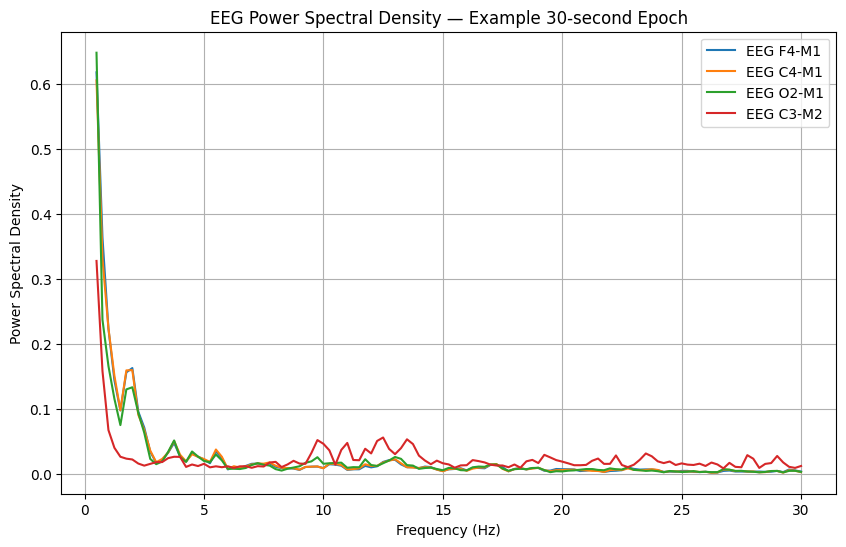

In [ ]:
# ============================================================
# CELL 5 — PSD VERIFICATION ON ONE EEG EPOCH
# ============================================================

from scipy.signal import welch
import matplotlib.pyplot as plt

# Select first epoch
epoch = X_sample[0]

# Frequency bands we will use later
BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "sigma": (12, 16),
    "beta": (16, 30)
}

# ------------------------------------------------------------
# Compute PSD for each EEG channel
# ------------------------------------------------------------

psd_results = {}

for ch in range(epoch.shape[0]):

    frequencies, psd = welch(
        epoch[ch],
        fs=SFREQ,
        nperseg=SFREQ * 4,     # 4-second Welch segments
        noverlap=SFREQ * 2     # 50% overlap
    )

    psd_results[ch] = {
        "frequencies": frequencies,
        "psd": psd
    }

# ------------------------------------------------------------
# Plot PSD
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for ch in range(epoch.shape[0]):

    frequencies = psd_results[ch]["frequencies"]
    psd = psd_results[ch]["psd"]

    # Only display frequencies relevant to our biomarkers
    mask = (frequencies >= 0.5) & (frequencies <= 30)

    plt.plot(
        frequencies[mask],
        psd[mask],
        label=CHANNEL_NAMES[ch]
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("EEG Power Spectral Density — Example 30-second Epoch")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# CELL 6 — EEG BIOMARKER EXTRACTION FUNCTION
# ============================================================

from scipy.signal import welch

# Frequency bands
BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "sigma": (12, 16),
    "beta": (16, 30)
}


def bandpower(frequencies, psd, low_freq, high_freq):
    """
    Calculate power contained within a frequency band
    using numerical integration of the PSD.
    """

    mask = (
        (frequencies >= low_freq) &
        (frequencies < high_freq)
    )

    if not np.any(mask):
        return 0.0

    return np.trapezoid(
        psd[mask],
        frequencies[mask]
    )


def extract_epoch_biomarkers(epoch, sfreq=100):
    """
    Extract spectral biomarkers from one 30-second
    multi-channel EEG epoch.

    Parameters
    ----------
    epoch : ndarray
        Shape: (channels, samples)

    sfreq : int
        Sampling frequency in Hz

    Returns
    -------
    features : dict
        Numerical EEG biomarker features.
    """

    features = {}

    # --------------------------------------------------------
    # Calculate PSD for each channel
    # --------------------------------------------------------

    channel_bandpowers = {
        band: []
        for band in BANDS
    }

    channel_total_power = []

    for ch in range(epoch.shape[0]):

        frequencies, psd = welch(
            epoch[ch],
            fs=sfreq,
            nperseg=sfreq * 4,
            noverlap=sfreq * 2
        )

        # Total power in 0.5–30 Hz
        total_power = bandpower(
            frequencies,
            psd,
            0.5,
            30
        )

        channel_total_power.append(total_power)

        # Power in each frequency band
        for band_name, (low, high) in BANDS.items():

            power = bandpower(
                frequencies,
                psd,
                low,
                high
            )

            channel_bandpowers[band_name].append(power)

    # --------------------------------------------------------
    # Average across the four EEG channels
    # --------------------------------------------------------

    mean_bandpowers = {}

    for band_name in BANDS:

        mean_bandpowers[band_name] = np.mean(
            channel_bandpowers[band_name]
        )

    mean_total_power = np.mean(channel_total_power)

    # --------------------------------------------------------
    # Absolute band powers
    # --------------------------------------------------------

    for band_name in BANDS:

        features[f"{band_name}_power"] = (
            mean_bandpowers[band_name]
        )

    # --------------------------------------------------------
    # Relative band powers
    # --------------------------------------------------------

    for band_name in BANDS:

        features[f"{band_name}_relative"] = (
            mean_bandpowers[band_name]
            / (mean_total_power + 1e-12)
        )

    # --------------------------------------------------------
    # Useful spectral ratios
    # --------------------------------------------------------

    features["sigma_delta_ratio"] = (
        mean_bandpowers["sigma"]
        / (mean_bandpowers["delta"] + 1e-12)
    )

    features["theta_delta_ratio"] = (
        mean_bandpowers["theta"]
        / (mean_bandpowers["delta"] + 1e-12)
    )

    features["alpha_delta_ratio"] = (
        mean_bandpowers["alpha"]
        / (mean_bandpowers["delta"] + 1e-12)
    )

    features["beta_delta_ratio"] = (
        mean_bandpowers["beta"]
        / (mean_bandpowers["delta"] + 1e-12)
    )

    return features

In [ ]:
# ============================================================
# CELL 7 — TEST BIOMARKER EXTRACTION
# ============================================================

features_test = extract_epoch_biomarkers(
    X_sample[0],
    sfreq=SFREQ
)

features_test_df = pd.DataFrame(
    [features_test]
)

print("Number of extracted features:",
      len(features_test))

print("\nExtracted biomarker values:")
display(features_test_df.T)

Number of extracted features: 14

Extracted biomarker values:


,0
delta_power,0.347809
theta_power,0.065069
alpha_power,0.059170
sigma_power,0.063899
beta_power,0.123533
delta_relative,0.512123
theta_relative,0.095809
alpha_relative,0.087124
sigma_relative,0.094086
beta_relative,0.181893


In [ ]:
# ============================================================
# CELL 8 — EXTRACT BIOMARKERS FOR ALL SUBJECTS
# ============================================================

def extract_subject_features(subject_id):
    """
    Extract EEG biomarkers for every epoch of one subject.

    Returns a DataFrame containing:
        subject
        epoch
        true_stage
        EEG biomarker features
    """

    file_path = os.path.join(
        PREPROC_PATH,
        f"{subject_id}.npz"
    )

    data = np.load(
        file_path,
        allow_pickle=True
    )

    X = data["X"]
    Y = data["Y"]

    rows = []

    for epoch_idx in range(len(Y)):

        features = extract_epoch_biomarkers(
            X[epoch_idx],
            sfreq=SFREQ
        )

        row = {
            "subject": subject_id,
            "epoch": epoch_idx,
            "true_stage": int(Y[epoch_idx])
        }

        row.update(features)

        rows.append(row)

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Extract train / validation / test separately
# ------------------------------------------------------------

print("Extracting TRAIN biomarkers...")

train_feature_dfs = []

for i, subject in enumerate(train_subjects):

    print(
        f"  [{i+1:02d}/{len(train_subjects)}] {subject}"
    )

    train_feature_dfs.append(
        extract_subject_features(subject)
    )


print("\nExtracting VALIDATION biomarkers...")

val_feature_dfs = []

for i, subject in enumerate(val_subjects):

    print(
        f"  [{i+1:02d}/{len(val_subjects)}] {subject}"
    )

    val_feature_dfs.append(
        extract_subject_features(subject)
    )


print("\nExtracting TEST biomarkers...")

test_feature_dfs = []

for i, subject in enumerate(test_subjects):

    print(
        f"  [{i+1:02d}/{len(test_subjects)}] {subject}"
    )

    test_feature_dfs.append(
        extract_subject_features(subject)
    )


# ------------------------------------------------------------
# Combine subjects
# ------------------------------------------------------------

train_features = pd.concat(
    train_feature_dfs,
    ignore_index=True
)

val_features = pd.concat(
    val_feature_dfs,
    ignore_index=True
)

test_features = pd.concat(
    test_feature_dfs,
    ignore_index=True
)


print("\n========================================")
print("FEATURE EXTRACTION COMPLETE")
print("========================================")

print("\nTrain shape:", train_features.shape)
print("Validation shape:", val_features.shape)
print("Test shape:", test_features.shape)

print("\nTrain subjects:", train_features["subject"].nunique())
print("Validation subjects:", val_features["subject"].nunique())
print("Test subjects:", test_features["subject"].nunique())

print("\nFirst five rows:")
display(train_features.head())

Extracting TRAIN biomarkers...
  [01/16] SN017
  [02/16] SN006
  [03/16] SN020
  [04/16] SN025
  [05/16] SN015
  [06/16] SN011
  [07/16] SN019
  [08/16] SN012
  [09/16] SN016
  [10/16] SN018
  [11/16] SN002
  [12/16] SN013
  [13/16] SN023
  [14/16] SN007
  [15/16] SN010
  [16/16] SN003

Extracting VALIDATION biomarkers...
  [01/4] SN024
  [02/4] SN005
  [03/4] SN021
  [04/4] SN008

Extracting TEST biomarkers...
  [01/4] SN009
  [02/4] SN001
  [03/4] SN004
  [04/4] SN022

FEATURE EXTRACTION COMPLETE

Train shape: (15216, 17)
Validation shape: (3619, 17)
Test shape: (3109, 17)

Train subjects: 16
Validation subjects: 4
Test subjects: 4

First five rows:


,subject,epoch,true_stage,delta_power,theta_power,alpha_power,sigma_power,beta_power,delta_relative,theta_relative,alpha_relative,sigma_relative,beta_relative,sigma_delta_ratio,theta_delta_ratio,alpha_delta_ratio,beta_delta_ratio
0,SN017,0,0,0.347809,0.065069,0.059170,0.063899,0.123533,0.512123,0.095809,0.087124,0.094086,0.181893,0.183718,0.187082,0.170123,0.355174
1,SN017,1,0,0.231114,0.012623,0.028721,0.036131,0.068949,0.600539,0.032800,0.074630,0.093885,0.179159,0.156335,0.054618,0.124272,0.298331
2,SN017,2,0,0.192789,0.025302,0.038101,0.031329,0.092105,0.497950,0.065353,0.098410,0.080918,0.237895,0.162503,0.131243,0.197631,0.477750
3,SN017,3,0,0.109503,0.019740,0.036883,0.020196,0.062549,0.428864,0.077312,0.144452,0.079098,0.244970,0.184436,0.180271,0.336826,0.571207
4,SN017,4,0,0.182511,0.048941,0.061598,0.041708,0.179838,0.344422,0.092358,0.116244,0.078708,0.339377,0.228522,0.268153,0.337506,0.985353


In [ ]:
# ============================================================
# CELL 9 — EXPLORATORY N1 vs N2 BIOMARKER ANALYSIS
# ============================================================

from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# Use TRAINING DATA ONLY
# ------------------------------------------------------------

n1_n2_train = train_features[
    train_features["true_stage"].isin([N1_LABEL, N2_LABEL])
].copy()

print("N1/N2 training epochs:", len(n1_n2_train))

print("\nClass counts:")
print(
    n1_n2_train["true_stage"]
    .map({N1_LABEL: "N1", N2_LABEL: "N2"})
    .value_counts()
)

# ------------------------------------------------------------
# Features to investigate
# ------------------------------------------------------------

BIOMARKER_FEATURES = [
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "sigma_relative",
    "beta_relative",
    "sigma_delta_ratio",
    "theta_delta_ratio",
    "alpha_delta_ratio",
    "beta_delta_ratio"
]

# ------------------------------------------------------------
# Compare N1 and N2
# ------------------------------------------------------------

rows = []

for feature in BIOMARKER_FEATURES:

    n1_values = n1_n2_train.loc[
        n1_n2_train["true_stage"] == N1_LABEL,
        feature
    ].values

    n2_values = n1_n2_train.loc[
        n1_n2_train["true_stage"] == N2_LABEL,
        feature
    ].values

    # AUC:
    # N2 = positive class
    y_binary = (
        n1_n2_train["true_stage"].values == N2_LABEL
    ).astype(int)

    feature_values = n1_n2_train[feature].values

    auc = roc_auc_score(
        y_binary,
        feature_values
    )

    # Symmetric measure:
    # distance of AUC from random (0.5)
    auc_separation = abs(auc - 0.5)

    rows.append({
        "feature": feature,
        "N1_mean": np.mean(n1_values),
        "N2_mean": np.mean(n2_values),
        "N1_median": np.median(n1_values),
        "N2_median": np.median(n2_values),
        "AUC": auc,
        "AUC_separation_from_0.5": auc_separation
    })


n1_n2_analysis = pd.DataFrame(rows)

# Sort by how strongly the feature separates N1 and N2
n1_n2_analysis = n1_n2_analysis.sort_values(
    "AUC_separation_from_0.5",
    ascending=False
).reset_index(drop=True)

print("\nN1 vs N2 biomarker analysis:")
display(n1_n2_analysis)

N1/N2 training epochs: 6807

Class counts:
true_stage
N2    5254
N1    1553
Name: count, dtype: int64

N1 vs N2 biomarker analysis:


,feature,N1_mean,N2_mean,N1_median,N2_median,AUC,AUC_separation_from_0.5
0,beta_delta_ratio,0.153878,0.049322,0.120353,0.036664,0.161433,0.338567
1,beta_relative,0.075599,0.031175,0.064585,0.025388,0.164910,0.335090
2,delta_relative,0.572886,0.699644,0.566317,0.701504,0.757483,0.257483
3,alpha_delta_ratio,0.266255,0.115737,0.190937,0.089526,0.255041,0.244959
4,sigma_delta_ratio,0.093994,0.052146,0.084268,0.043436,0.266815,0.233185
5,alpha_relative,0.120804,0.071225,0.105926,0.061935,0.270273,0.229727
6,sigma_relative,0.046407,0.033424,0.045101,0.030258,0.304914,0.195086
7,theta_delta_ratio,0.309078,0.215545,0.273270,0.198033,0.331435,0.168565
8,theta_relative,0.152831,0.139054,0.152925,0.138018,0.417072,0.082928


In [ ]:
# ============================================================
# CELL 10 — SUBJECT-WISE N1/N2 BIOMARKER SEPARATION
# ============================================================

# We will calculate AUC separately for each training subject.
# This checks whether the separation is consistent across people.

subject_results = []

for subject in train_subjects:

    subject_data = train_features[
        train_features["subject"] == subject
    ].copy()

    # Keep only N1 and N2
    subject_data = subject_data[
        subject_data["true_stage"].isin(
            [N1_LABEL, N2_LABEL]
        )
    ]

    # We need both N1 and N2 present
    if subject_data["true_stage"].nunique() < 2:
        continue

    y_subject = (
        subject_data["true_stage"].values == N2_LABEL
    ).astype(int)

    row = {
        "subject": subject,
        "N1_epochs": np.sum(
            subject_data["true_stage"].values == N1_LABEL
        ),
        "N2_epochs": np.sum(
            subject_data["true_stage"].values == N2_LABEL
        )
    }

    for feature in BIOMARKER_FEATURES:

        values = subject_data[feature].values

        try:
            auc = roc_auc_score(
                y_subject,
                values
            )

            row[feature] = auc

        except ValueError:
            row[feature] = np.nan

    subject_results.append(row)


subject_auc_df = pd.DataFrame(subject_results)

print("Subject-wise AUC results:")
display(subject_auc_df)

Subject-wise AUC results:


,subject,N1_epochs,N2_epochs,delta_relative,theta_relative,alpha_relative,sigma_relative,beta_relative,sigma_delta_ratio,theta_delta_ratio,alpha_delta_ratio,beta_delta_ratio
0,SN017,134,397,0.824805,0.499812,0.236870,0.344148,0.072841,0.256382,0.316534,0.197000,0.084270
1,SN006,153,350,0.620710,0.512213,0.351485,0.294846,0.219739,0.311989,0.451242,0.355854,0.239384
2,SN020,67,325,0.593984,0.472882,0.498921,0.477704,0.216716,0.453685,0.456303,0.475132,0.223513
3,SN025,149,400,0.715721,0.479329,0.280503,0.303758,0.274094,0.283591,0.378507,0.278674,0.270302
4,SN015,127,161,0.788526,0.396488,0.345772,0.205409,0.101384,0.200176,0.313298,0.279992,0.114736
5,SN011,250,504,0.754159,0.361310,0.312167,0.200770,0.148468,0.204706,0.286484,0.282421,0.155325
6,SN019,81,188,0.892895,0.280273,0.109141,0.106449,0.080575,0.094431,0.154846,0.103888,0.076175
7,SN012,55,280,0.846494,0.422078,0.091948,0.321299,0.080714,0.247403,0.279675,0.098442,0.077792
8,SN016,19,423,0.742192,0.645888,0.242503,0.112853,0.018042,0.136120,0.499067,0.239393,0.020406
9,SN018,61,443,0.758428,0.301558,0.238130,0.257817,0.235762,0.241609,0.256041,0.235392,0.234245


In [ ]:
# ============================================================
# CELL 11 — SUMMARY OF SUBJECT-WISE AUC
# ============================================================

auc_columns = BIOMARKER_FEATURES

summary_rows = []

for feature in auc_columns:

    values = subject_auc_df[feature].dropna()

    # Distance from random guessing
    separation = np.abs(values - 0.5)

    summary_rows.append({
        "feature": feature,
        "mean_AUC": values.mean(),
        "median_AUC": values.median(),
        "std_AUC": values.std(),
        "mean_abs_separation": separation.mean(),
        "subjects_AUC_above_0.5": np.sum(values > 0.5),
        "subjects_AUC_below_0.5": np.sum(values < 0.5)
    })


subject_auc_summary = pd.DataFrame(
    summary_rows
)

subject_auc_summary = subject_auc_summary.sort_values(
    "mean_abs_separation",
    ascending=False
).reset_index(drop=True)

print("Subject-wise biomarker separation summary:")
display(subject_auc_summary)

Subject-wise biomarker separation summary:


,feature,mean_AUC,median_AUC,std_AUC,mean_abs_separation,subjects_AUC_above_0.5,subjects_AUC_below_0.5
0,beta_relative,0.115399,0.086104,0.079674,0.384601,0,16
1,beta_delta_ratio,0.122289,0.099503,0.079114,0.377711,0,16
2,delta_relative,0.773428,0.780835,0.087282,0.273428,16,0
3,alpha_delta_ratio,0.236806,0.237392,0.096683,0.263194,0,16
4,sigma_delta_ratio,0.240973,0.244337,0.097687,0.259027,0,16
5,alpha_relative,0.254852,0.240317,0.104139,0.245148,0,16
6,sigma_relative,0.264058,0.276332,0.111577,0.235942,0,16
7,theta_delta_ratio,0.336086,0.314916,0.090795,0.163914,0,16
8,theta_relative,0.442952,0.454450,0.088905,0.076811,2,14


In [ ]:
# ============================================================
# CELL 12 — LOAD EXISTING TRANSFORMER MODEL
# ============================================================

# ------------------------------------------------------------
# Evidential helper functions
# ------------------------------------------------------------

def evidence_to_probs(evidence):
    evidence = tf.convert_to_tensor(
        evidence,
        dtype=tf.float32
    )

    alpha = evidence + 1.0

    S = tf.reduce_sum(
        alpha,
        axis=-1,
        keepdims=True
    )

    probs = alpha / S

    return probs


def evidence_to_uncertainty(
    evidence,
    num_classes=5
):
    evidence = tf.convert_to_tensor(
        evidence,
        dtype=tf.float32
    )

    alpha = evidence + 1.0

    S = tf.reduce_sum(
        alpha,
        axis=-1,
        keepdims=True
    )

    uncertainty = num_classes / S

    return uncertainty


# ------------------------------------------------------------
# Exact evidential loss used by the original model
# ------------------------------------------------------------

def evidential_loss(y_true, evidence):

    y_true = tf.cast(
        y_true,
        tf.int32
    )

    y_onehot = tf.one_hot(
        y_true,
        depth=NUM_CLASSES
    )

    # Label smoothing used in the original model
    y_onehot = (
        0.95 * y_onehot
        + 0.05 / NUM_CLASSES
    )

    alpha = evidence + 1.0

    S = tf.reduce_sum(
        alpha,
        axis=-1,
        keepdims=True
    )

    probs = alpha / S

    ce = -tf.reduce_sum(
        y_onehot *
        tf.math.log(probs + 1e-8),
        axis=-1
    )

    reg = tf.reduce_sum(
        (alpha - 1.0) *
        (1.0 - y_onehot),
        axis=-1
    ) / NUM_CLASSES

    return ce + 0.003 * reg


def evidential_accuracy(y_true, evidence):

    probs = evidence_to_probs(evidence)

    return tf.keras.metrics.sparse_categorical_accuracy(
        y_true,
        probs
    )


# ------------------------------------------------------------
# Load the EXISTING saved Transformer
# ------------------------------------------------------------

print("Loading existing Transformer model...")

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "evidential_loss": evidential_loss,
        "evidential_accuracy": evidential_accuracy
    },
    compile=False
)

print("\nModel loaded successfully.")

print("\nModel input shape:")
print(model.input_shape)

print("\nModel output shape:")
print(model.output_shape)

Loading existing Transformer model...

Model loaded successfully.

Model input shape:
(None, 4, 3000)

Model output shape:
(None, 5)


In [ ]:
# ============================================================
# CELL 13 — GENERATE BASELINE TRANSFORMER PREDICTIONS
# ============================================================

BATCH_SIZE = 128


def predict_subject(subject_id):
    """
    Run the existing Transformer on one subject.

    Returns a DataFrame containing:
        subject
        epoch
        true_stage
        predicted_stage
        uncertainty
        probability for each class
    """

    file_path = os.path.join(
        PREPROC_PATH,
        f"{subject_id}.npz"
    )

    data = np.load(
        file_path,
        allow_pickle=True
    )

    X = data["X"].astype(np.float32)
    Y = data["Y"].astype(np.int32)

    # --------------------------------------------------------
    # IMPORTANT:
    # Use the same per-epoch normalization as the
    # original project.
    # --------------------------------------------------------

    mean = np.mean(
        X,
        axis=2,
        keepdims=True
    )

    std = np.std(
        X,
        axis=2,
        keepdims=True
    ) + 1e-6

    X_normalized = (
        (X - mean) / std
    ).astype(np.float32)

    # --------------------------------------------------------
    # Transformer prediction
    # --------------------------------------------------------

    evidence = model.predict(
        X_normalized,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    # Convert evidential output to probabilities
    probabilities = evidence_to_probs(
        evidence
    ).numpy()

    # Convert evidential output to uncertainty
    uncertainty = evidence_to_uncertainty(
        evidence,
        NUM_CLASSES
    ).numpy().squeeze()

    # Predicted class
    predictions = np.argmax(
        probabilities,
        axis=1
    )

    # --------------------------------------------------------
    # Build result table
    # --------------------------------------------------------

    result = pd.DataFrame({
        "subject": subject_id,
        "epoch": np.arange(len(Y)),
        "true_stage": Y,
        "predicted_stage": predictions,
        "uncertainty": uncertainty
    })

    # Add class probabilities
    for i, class_name in enumerate(CLASS_NAMES):

        result[f"prob_{class_name}"] = (
            probabilities[:, i]
        )

    return result

In [ ]:
# ============================================================
# CELL 14 — PREDICT ALL TRAIN / VAL / TEST SUBJECTS
# ============================================================

def predict_subject_list(subject_list, split_name):

    results = []

    print(f"\nGenerating {split_name} predictions...")

    for i, subject in enumerate(subject_list):

        print(
            f"  [{i+1:02d}/{len(subject_list)}] {subject}"
        )

        subject_result = predict_subject(
            subject
        )

        results.append(subject_result)

    return pd.concat(
        results,
        ignore_index=True
    )


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

baseline_train = predict_subject_list(
    train_subjects,
    "TRAIN"
)

baseline_val = predict_subject_list(
    val_subjects,
    "VALIDATION"
)

baseline_test = predict_subject_list(
    test_subjects,
    "TEST"
)


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print("\n========================================")
print("BASELINE PREDICTIONS COMPLETE")
print("========================================")

print("\nTrain:", baseline_train.shape)
print("Validation:", baseline_val.shape)
print("Test:", baseline_test.shape)

print("\nExample test predictions:")
display(
    baseline_test.head(10)
)


Generating TRAIN predictions...
  [01/16] SN017
  [02/16] SN006
  [03/16] SN020
  [04/16] SN025
  [05/16] SN015
  [06/16] SN011
  [07/16] SN019
  [08/16] SN012
  [09/16] SN016
  [10/16] SN018
  [11/16] SN002
  [12/16] SN013
  [13/16] SN023
  [14/16] SN007
  [15/16] SN010
  [16/16] SN003

Generating VALIDATION predictions...
  [01/4] SN024
  [02/4] SN005
  [03/4] SN021
  [04/4] SN008

Generating TEST predictions...
  [01/4] SN009
  [02/4] SN001
  [03/4] SN004
  [04/4] SN022

BASELINE PREDICTIONS COMPLETE

Train: (15216, 10)
Validation: (3619, 10)
Test: (3109, 10)

Example test predictions:


,subject,epoch,true_stage,predicted_stage,uncertainty,prob_W,prob_N1,prob_N2,prob_N3,prob_REM
0,SN009,0,0,0,0.214072,0.643423,0.227946,0.042844,0.042835,0.042952
1,SN009,1,0,0,0.203592,0.805034,0.072657,0.040724,0.040820,0.040764
2,SN009,2,0,0,0.220148,0.631890,0.235431,0.044422,0.044061,0.044196
3,SN009,3,0,0,0.199548,0.816900,0.063211,0.039912,0.040023,0.039954
4,SN009,4,0,0,0.201234,0.813684,0.065425,0.040249,0.040344,0.040298
5,SN009,5,0,0,0.207557,0.759315,0.115970,0.041516,0.041564,0.041634
6,SN009,6,0,0,0.227763,0.573552,0.288403,0.046536,0.045573,0.045936
7,SN009,7,0,0,0.201638,0.774124,0.104760,0.040333,0.040372,0.040411
8,SN009,8,0,0,0.203240,0.801768,0.076143,0.040650,0.040733,0.040706
9,SN009,9,0,0,0.202543,0.756154,0.122181,0.040516,0.040564,0.040586


In [ ]:
# ============================================================
# CELL 15 — CURRENT TEST-SET BASELINE
# ============================================================

y_true = baseline_test["true_stage"].values
y_pred = baseline_test["predicted_stage"].values

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print("========================================")
print("CURRENT TEST-SET BASELINE")
print("========================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{x}" for x in CLASS_NAMES],
    columns=[f"Pred_{x}" for x in CLASS_NAMES]
)

display(cm_df)

CURRENT TEST-SET BASELINE
Accuracy : 0.5545
Macro F1 : 0.5742

Classification Report:
              precision    recall  f1-score   support

           W     0.6421    0.7896    0.7083       309
          N1     0.2529    0.6625    0.3660       397
          N2     0.6681    0.4988    0.5712      1283
          N3     0.8472    0.6203    0.7162       590
         REM     0.7057    0.3981    0.5090       530

    accuracy                         0.5545      3109
   macro avg     0.6232    0.5939    0.5742      3109
weighted avg     0.6529    0.5545    0.5755      3109


Confusion Matrix:


,Pred_W,Pred_N1,Pred_N2,Pred_N3,Pred_REM
True_W,244,63,0,0,2
True_N1,96,263,15,0,23
True_N2,16,506,640,60,61
True_N3,0,3,219,366,2
True_REM,24,205,84,6,211


In [ ]:
# ============================================================
# CELL 16 — N1 / N2 BASELINE ANALYSIS
# ============================================================

n1_n2_mask = (
    baseline_test["true_stage"].isin([N1_LABEL, N2_LABEL])
)

n1_n2 = baseline_test[n1_n2_mask].copy()

print("========================================")
print("N1 / N2 BASELINE ANALYSIS")
print("========================================")

print(f"True N1/N2 epochs: {len(n1_n2)}")

print("\nTrue N1/N2 → Predicted:")
display(
    pd.crosstab(
        n1_n2["true_stage"].map(
            {N1_LABEL: "N1", N2_LABEL: "N2"}
        ),
        n1_n2["predicted_stage"].map(
            dict(enumerate(CLASS_NAMES))
        )
    )
)

# Only epochs whose Transformer prediction is N1 or N2
candidate_mask = baseline_test["predicted_stage"].isin(
    [N1_LABEL, N2_LABEL]
)

candidates = baseline_test[candidate_mask].copy()

print("\n----------------------------------------")
print("Transformer N1/N2 candidate epochs")
print("----------------------------------------")

print(f"Total candidates: {len(candidates)}")

print("\nCandidate true-stage distribution:")
print(
    candidates["true_stage"]
    .map(dict(enumerate(CLASS_NAMES)))
    .value_counts()
)

print("\nCandidate confusion:")
display(
    pd.crosstab(
        candidates["true_stage"].map(
            dict(enumerate(CLASS_NAMES))
        ),
        candidates["predicted_stage"].map(
            dict(enumerate(CLASS_NAMES))
        )
    )
)

N1 / N2 BASELINE ANALYSIS
True N1/N2 epochs: 1680

True N1/N2 → Predicted:


predicted_stage,N1,N2,N3,REM,W
true_stage,,,,,
N1,263,15,0,23,96
N2,506,640,60,61,16



----------------------------------------
Transformer N1/N2 candidate epochs
----------------------------------------
Total candidates: 1998

Candidate true-stage distribution:
true_stage
N2     1146
REM     289
N1      278
N3      222
W        63
Name: count, dtype: int64

Candidate confusion:


predicted_stage,N1,N2
true_stage,,
N1,263,15
N2,506,640
N3,3,219
REM,205,84
W,63,0


In [ ]:
# ============================================================
# CELL 17 — BUILD N1/N2 REFINEMENT DATASETS
# ============================================================

BIOMARKER_FEATURES = [
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "sigma_relative",
    "beta_relative",
    "sigma_delta_ratio",
    "theta_delta_ratio",
    "alpha_delta_ratio",
    "beta_delta_ratio"
]


def build_refinement_dataset(
    biomarker_df,
    baseline_df,
    split_name
):
    """
    Build the N1/N2 refinement dataset.

    Include only epochs where:
      1. Transformer predicted N1 or N2
      2. True stage is N1 or N2

    Target:
      0 = N1
      1 = N2
    """

    merged = biomarker_df.merge(
        baseline_df[
            [
                "subject",
                "epoch",
                "predicted_stage"
            ]
        ],
        on=["subject", "epoch"],
        how="inner"
    )

    # Transformer predicted N1 or N2
    candidate_mask = merged[
        "predicted_stage"
    ].isin([N1_LABEL, N2_LABEL])

    # Ground truth is actually N1 or N2
    true_n1_n2_mask = merged[
        "true_stage"
    ].isin([N1_LABEL, N2_LABEL])

    refinement = merged[
        candidate_mask & true_n1_n2_mask
    ].copy()

    # N1 = 0, N2 = 1
    refinement["target"] = (
        refinement["true_stage"] == N2_LABEL
    ).astype(int)

    X = refinement[
        BIOMARKER_FEATURES
    ].values.astype(np.float32)

    y = refinement[
        "target"
    ].values.astype(np.int32)

    print(f"\n{split_name} refinement dataset")
    print("----------------------------------------")
    print("Samples:", len(refinement))
    print("N1:", np.sum(y == 0))
    print("N2:", np.sum(y == 1))

    return refinement, X, y


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

train_refinement, X_ref_train, y_ref_train = \
    build_refinement_dataset(
        train_features,
        baseline_train,
        "TRAIN"
    )


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

val_refinement, X_ref_val, y_ref_val = \
    build_refinement_dataset(
        val_features,
        baseline_val,
        "VALIDATION"
    )


TRAIN refinement dataset
----------------------------------------
Samples: 5866
N1: 1278
N2: 4588

VALIDATION refinement dataset
----------------------------------------
Samples: 1442
N1: 342
N2: 1100


In [ ]:
# ============================================================
# CELL 18 — TRAIN N1/N2 BIOMARKER REFINEMENT MODEL
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Build pipeline
# ------------------------------------------------------------

refinement_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=SEED
        )
    )
])


# ------------------------------------------------------------
# Train ONLY on training subjects
# ------------------------------------------------------------

refinement_model.fit(
    X_ref_train,
    y_ref_train
)

print("N1/N2 refinement model trained successfully.")

N1/N2 refinement model trained successfully.


In [ ]:
# ============================================================
# CELL 19 — VALIDATION PERFORMANCE OF REFINEMENT MODEL
# ============================================================

val_ref_pred = refinement_model.predict(
    X_ref_val
)

val_accuracy = accuracy_score(
    y_ref_val,
    val_ref_pred
)

val_macro_f1 = f1_score(
    y_ref_val,
    val_ref_pred,
    average="macro"
)

print("========================================")
print("N1/N2 REFINEMENT — VALIDATION")
print("========================================")

print(f"Accuracy : {val_accuracy:.4f}")
print(f"Macro F1 : {val_macro_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_ref_val,
        val_ref_pred,
        labels=[0, 1],
        target_names=["N1", "N2"],
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix:")

cm_ref_val = confusion_matrix(
    y_ref_val,
    val_ref_pred,
    labels=[0, 1]
)

cm_ref_val_df = pd.DataFrame(
    cm_ref_val,
    index=["True_N1", "True_N2"],
    columns=["Pred_N1", "Pred_N2"]
)

display(cm_ref_val_df)

N1/N2 REFINEMENT — VALIDATION
Accuracy : 0.7913
Macro F1 : 0.7257

Classification Report:
              precision    recall  f1-score   support

          N1     0.5519    0.6374    0.5916       342
          N2     0.8816    0.8391    0.8598      1100

    accuracy                         0.7913      1442
   macro avg     0.7167    0.7383    0.7257      1442
weighted avg     0.8034    0.7913    0.7962      1442


Confusion Matrix:


,Pred_N1,Pred_N2
True_N1,218,124
True_N2,177,923


In [ ]:
# ============================================================
# CELL 20 — BIOMARKER MODEL COEFFICIENTS
# ============================================================

logreg = refinement_model.named_steps["classifier"]

coefficients = pd.DataFrame({
    "feature": BIOMARKER_FEATURES,
    "coefficient": logreg.coef_[0]
})

coefficients["abs_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "abs_coefficient",
    ascending=False
)

print("========================================")
print("BIOMARKER REFINEMENT COEFFICIENTS")
print("========================================")

display(
    coefficients[
        ["feature", "coefficient"]
    ]
)

BIOMARKER REFINEMENT COEFFICIENTS


,feature,coefficient
3,sigma_relative,2.135340
4,beta_relative,-1.783098
5,sigma_delta_ratio,-1.435955
1,theta_relative,1.377252
6,theta_delta_ratio,-1.066003
7,alpha_delta_ratio,0.994630
2,alpha_relative,-0.826812
0,delta_relative,0.762471
8,beta_delta_ratio,0.308964


In [ ]:
# ============================================================
# CELL 21 — BIOMARKER-ASSISTED TEST PREDICTIONS
# ============================================================

# Copy the original Transformer predictions
baseline_refined_test = baseline_test.copy()

# Identify all epochs where Transformer predicted N1 or N2
test_candidate_mask = baseline_refined_test[
    "predicted_stage"
].isin([N1_LABEL, N2_LABEL])

test_candidates = baseline_refined_test[
    test_candidate_mask
].copy()

print("========================================")
print("TEST N1/N2 CANDIDATES")
print("========================================")

print(
    f"Total Transformer N1/N2 candidates: "
    f"{len(test_candidates)}"
)

# ------------------------------------------------------------
# Get biomarker features for these exact epochs
# ------------------------------------------------------------

test_candidate_features = test_candidates[
    ["subject", "epoch"]
].merge(
    test_features[
        ["subject", "epoch"] + BIOMARKER_FEATURES
    ],
    on=["subject", "epoch"],
    how="left"
)

# Sanity check
assert len(test_candidate_features) == len(
    test_candidates
)

assert not test_candidate_features[
    BIOMARKER_FEATURES
].isnull().any().any()

# ------------------------------------------------------------
# Biomarker refinement prediction
# ------------------------------------------------------------

X_test_refine = test_candidate_features[
    BIOMARKER_FEATURES
].values.astype(np.float32)

refined_binary = refinement_model.predict(
    X_test_refine
)

# Binary mapping:
# 0 -> N1
# 1 -> N2

refined_stage = np.where(
    refined_binary == 0,
    N1_LABEL,
    N2_LABEL
)

# ------------------------------------------------------------
# Replace ONLY N1/N2 Transformer predictions
# ------------------------------------------------------------

baseline_refined_test.loc[
    test_candidate_mask,
    "refined_stage"
] = refined_stage

# Everything outside N1/N2 candidates remains unchanged
baseline_refined_test.loc[
    ~test_candidate_mask,
    "refined_stage"
] = baseline_refined_test.loc[
    ~test_candidate_mask,
    "predicted_stage"
]

baseline_refined_test[
    "refined_stage"
] = baseline_refined_test[
    "refined_stage"
].astype(int)

print("\nBiomarker-assisted predictions generated.")

print("\nPrediction counts:")
print(
    baseline_refined_test[
        "refined_stage"
    ].map(dict(enumerate(CLASS_NAMES))).value_counts()
)

TEST N1/N2 CANDIDATES
Total Transformer N1/N2 candidates: 1998

Biomarker-assisted predictions generated.

Prediction counts:
refined_stage
N2     1130
N1      868
N3      432
W       380
REM     299
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 22 — BASELINE VS BIOMARKER REFINEMENT
# ============================================================

y_test = baseline_refined_test[
    "true_stage"
].values

baseline_pred = baseline_refined_test[
    "predicted_stage"
].values

refined_pred = baseline_refined_test[
    "refined_stage"
].values


def evaluate_predictions(
    y_true,
    y_pred,
    name
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    print(f"\n{'=' * 50}")
    print(name)
    print(f"{'=' * 50}")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")

    print("\nClass-wise F1:")

    for stage in CLASS_NAMES:
        print(
            f"{stage:>4}: "
            f"{report[stage]['f1-score']:.4f}"
        )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "report": report
    }


baseline_results = evaluate_predictions(
    y_test,
    baseline_pred,
    "ORIGINAL TRANSFORMER"
)

refined_results = evaluate_predictions(
    y_test,
    refined_pred,
    "TRANSFORMER + BIOMARKER REFINEMENT"
)


print("\n========================================")
print("CHANGE")
print("========================================")

print(
    f"Accuracy change : "
    f"{refined_results['accuracy'] - baseline_results['accuracy']:+.4f}"
)

print(
    f"Macro F1 change : "
    f"{refined_results['macro_f1'] - baseline_results['macro_f1']:+.4f}"
)

print(
    f"N1 F1 change    : "
    f"{refined_results['report']['N1']['f1-score'] - baseline_results['report']['N1']['f1-score']:+.4f}"
)

print(
    f"N2 F1 change    : "
    f"{refined_results['report']['N2']['f1-score'] - baseline_results['report']['N2']['f1-score']:+.4f}"
)


ORIGINAL TRANSFORMER
Accuracy : 0.5545
Macro F1 : 0.5742

Class-wise F1:
   W: 0.7083
  N1: 0.3660
  N2: 0.5712
  N3: 0.7162
 REM: 0.5090

TRANSFORMER + BIOMARKER REFINEMENT
Accuracy : 0.5934
Macro F1 : 0.5951

Class-wise F1:
   W: 0.7083
  N1: 0.4063
  N2: 0.6357
  N3: 0.7162
 REM: 0.5090

CHANGE
Accuracy change : +0.0389
Macro F1 change : +0.0210
N1 F1 change    : +0.0403
N2 F1 change    : +0.0645


In [ ]:
# ============================================================
# CELL 23 — ANALYZE REFINEMENT CHANGES
# ============================================================

analysis = baseline_refined_test.copy()

analysis["baseline_correct"] = (
    analysis["predicted_stage"]
    == analysis["true_stage"]
)

analysis["refined_correct"] = (
    analysis["refined_stage"]
    == analysis["true_stage"]
)

analysis["change_type"] = "UNCHANGED"

# Corrected by refinement
analysis.loc[
    (~analysis["baseline_correct"]) &
    (analysis["refined_correct"]),
    "change_type"
] = "CORRECTED"

# Correct baseline prediction became wrong
analysis.loc[
    (analysis["baseline_correct"]) &
    (~analysis["refined_correct"]),
    "change_type"
] = "DEGRADED"

# Wrong baseline remained wrong, but prediction changed
analysis.loc[
    (~analysis["baseline_correct"]) &
    (~analysis["refined_correct"]) &
    (
        analysis["predicted_stage"]
        != analysis["refined_stage"]
    ),
    "change_type"
] = "WRONG_TO_WRONG"


print("========================================")
print("REFINEMENT CHANGE ANALYSIS")
print("========================================")

print(
    analysis["change_type"]
    .value_counts()
)

print("\n")


# ------------------------------------------------------------
# Baseline → Refined transitions
# ------------------------------------------------------------

changed = analysis[
    analysis["predicted_stage"]
    != analysis["refined_stage"]
].copy()

changed["baseline_label"] = changed[
    "predicted_stage"
].map(dict(enumerate(CLASS_NAMES)))

changed["refined_label"] = changed[
    "refined_stage"
].map(dict(enumerate(CLASS_NAMES)))

changed["true_label"] = changed[
    "true_stage"
].map(dict(enumerate(CLASS_NAMES)))


print("========================================")
print("ALL CHANGED PREDICTIONS")
print("========================================")

print(
    f"Total changed epochs: {len(changed)}"
)

display(
    pd.crosstab(
        changed["baseline_label"],
        changed["refined_label"],
        rownames=["Baseline"],
        colnames=["Refined"]
    )
)


# ------------------------------------------------------------
# N1/N2-specific changes
# ------------------------------------------------------------

n1_n2_changes = changed[
    changed["baseline_label"].isin(["N1", "N2"]) &
    changed["refined_label"].isin(["N1", "N2"])
].copy()

print("\n========================================")
print("N1 ↔ N2 CHANGES")
print("========================================")

print(
    f"N1/N2 changes: {len(n1_n2_changes)}"
)

display(
    pd.crosstab(
        n1_n2_changes["true_label"],
        [
            n1_n2_changes["baseline_label"],
            n1_n2_changes["refined_label"]
        ]
    )
)


# ------------------------------------------------------------
# Corrected / degraded examples
# ------------------------------------------------------------

print("\n========================================")
print("CORRECTED PREDICTIONS")
print("========================================")

corrected = analysis[
    analysis["change_type"] == "CORRECTED"
]

print(
    f"Corrected: {len(corrected)}"
)

display(
    corrected[
        [
            "subject",
            "epoch",
            "true_stage",
            "predicted_stage",
            "refined_stage"
        ]
    ].head(20)
)


print("\n========================================")
print("DEGRADED PREDICTIONS")
print("========================================")

degraded = analysis[
    analysis["change_type"] == "DEGRADED"
]

print(
    f"Degraded: {len(degraded)}"
)

display(
    degraded[
        [
            "subject",
            "epoch",
            "true_stage",
            "predicted_stage",
            "refined_stage"
        ]
    ].head(20)
)

REFINEMENT CHANGE ANALYSIS
change_type
UNCHANGED         2871
CORRECTED          154
WRONG_TO_WRONG      51
DEGRADED            33
Name: count, dtype: int64


ALL CHANGED PREDICTIONS
Total changed epochs: 238


Refined,N1,N2
Baseline,,
N1,0,205
N2,33,0



N1 ↔ N2 CHANGES
N1/N2 changes: 238


baseline_label,N1,N2
refined_label,N2,N1
true_label,,
N1,9,3
N2,151,24
N3,3,4
REM,40,2
W,2,0



CORRECTED PREDICTIONS
Corrected: 154


,subject,epoch,true_stage,predicted_stage,refined_stage
208,SN009,208,2,1,2
209,SN009,209,2,1,2
210,SN009,210,2,1,2
217,SN009,217,2,1,2
218,SN009,218,2,1,2
220,SN009,220,2,1,2
225,SN009,225,2,1,2
226,SN009,226,2,1,2
236,SN009,236,2,1,2
238,SN009,238,2,1,2



DEGRADED PREDICTIONS
Degraded: 33


,subject,epoch,true_stage,predicted_stage,refined_stage
206,SN009,206,1,1,2
466,SN009,466,2,2,1
477,SN009,477,2,2,1
505,SN009,505,1,1,2
642,SN009,642,2,2,1
656,SN009,656,1,1,2
752,SN009,752,1,1,2
872,SN009,872,2,2,1
1032,SN001,131,2,2,1
1148,SN004,57,2,2,1


In [ ]:
# ============================================================
# CELL 24 — SUBJECT-WISE BASELINE VS REFINED PERFORMANCE
# ============================================================

subject_results = []

for subject in test_subjects:

    sub = analysis[
        analysis["subject"] == subject
    ]

    y_true_sub = sub["true_stage"].values

    baseline_sub = sub[
        "predicted_stage"
    ].values

    refined_sub = sub[
        "refined_stage"
    ].values

    subject_results.append({
        "subject": subject,

        "baseline_accuracy": accuracy_score(
            y_true_sub,
            baseline_sub
        ),

        "refined_accuracy": accuracy_score(
            y_true_sub,
            refined_sub
        ),

        "accuracy_change": (
            accuracy_score(
                y_true_sub,
                refined_sub
            )
            -
            accuracy_score(
                y_true_sub,
                baseline_sub
            )
        ),

        "baseline_macro_f1": f1_score(
            y_true_sub,
            baseline_sub,
            average="macro"
        ),

        "refined_macro_f1": f1_score(
            y_true_sub,
            refined_sub,
            average="macro"
        )
    })


subject_results_df = pd.DataFrame(
    subject_results
)

print("========================================")
print("SUBJECT-WISE RESULTS")
print("========================================")

display(subject_results_df)

SUBJECT-WISE RESULTS


,subject,baseline_accuracy,refined_accuracy,accuracy_change,baseline_macro_f1,refined_macro_f1
0,SN009,0.612653,0.644839,0.032186,0.616853,0.639365
1,SN001,0.468421,0.484211,0.015789,0.390344,0.401769
2,SN004,0.567913,0.640748,0.072835,0.595188,0.627846
3,SN022,0.504990,0.519960,0.014970,0.551397,0.559362


In [ ]:
print("========================================")
print("BASELINE CONFUSION MATRIX")
print("========================================")

cm_baseline = confusion_matrix(
    y_test,
    baseline_pred,
    labels=np.arange(NUM_CLASSES)
)

cm_baseline_df = pd.DataFrame(
    cm_baseline,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

display(cm_baseline_df)


print("========================================")
print("REFINED CONFUSION MATRIX")
print("========================================")

cm_refined = confusion_matrix(
    y_test,
    refined_pred,
    labels=np.arange(NUM_CLASSES)
)

cm_refined_df = pd.DataFrame(
    cm_refined,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

display(cm_refined_df)

BASELINE CONFUSION MATRIX


,W,N1,N2,N3,REM
W,244,63,0,0,2
N1,96,263,15,0,23
N2,16,506,640,60,61
N3,0,3,219,366,2
REM,24,205,84,6,211


REFINED CONFUSION MATRIX


,W,N1,N2,N3,REM
W,244,61,2,0,2
N1,96,257,21,0,23
N2,16,379,767,60,61
N3,0,4,218,366,2
REM,24,167,122,6,211


In [ ]:
mask_n1n2 = np.isin(y_test, [N1_LABEL, N2_LABEL])

print("========================================")
print("N1/N2 ONLY")
print("========================================")

cm_n1n2_baseline = confusion_matrix(
    y_test[mask_n1n2],
    baseline_pred[mask_n1n2],
    labels=[N1_LABEL, N2_LABEL]
)

cm_n1n2_refined = confusion_matrix(
    y_test[mask_n1n2],
    refined_pred[mask_n1n2],
    labels=[N1_LABEL, N2_LABEL]
)

print("Baseline:")
display(pd.DataFrame(
    cm_n1n2_baseline,
    index=["True N1", "True N2"],
    columns=["Pred N1", "Pred N2"]
))

print("Refined:")
display(pd.DataFrame(
    cm_n1n2_refined,
    index=["True N1", "True N2"],
    columns=["Pred N1", "Pred N2"]
))

N1/N2 ONLY
Baseline:


,Pred N1,Pred N2
True N1,263,15
True N2,506,640


Refined:


,Pred N1,Pred N2
True N1,257,21
True N2,379,767


In [ ]:
# ========================================
# SLEEP ARCHITECTURE ANALYSIS
# ========================================

STAGE_NAMES = {
    0: "W",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "REM"
}

SLEEP_STAGES = [1, 2, 3, 4]   # N1, N2, N3, REM


def calculate_sleep_metrics(stages, epoch_seconds=30):
    """
    Calculate sleep-architecture metrics from a sequence
    of 30-second sleep-stage labels.

    Stages:
        0 = W
        1 = N1
        2 = N2
        3 = N3
        4 = REM
    """

    stages = np.asarray(stages, dtype=int)

    n_epochs = len(stages)
    total_recording_time = n_epochs * epoch_seconds

    # Sleep = N1 + N2 + N3 + REM
    sleep_mask = np.isin(stages, SLEEP_STAGES)

    # Total Sleep Time
    tst_seconds = np.sum(sleep_mask) * epoch_seconds
    tst_minutes = tst_seconds / 60

    # Recording-window sleep efficiency
    sleep_efficiency = (
        tst_seconds / total_recording_time * 100
        if total_recording_time > 0 else np.nan
    )

    # ------------------------------------------------
    # Sleep onset
    # ------------------------------------------------

    sleep_indices = np.where(sleep_mask)[0]

    if len(sleep_indices) > 0:
        sleep_onset_epoch = sleep_indices[0]
        sleep_onset_latency_min = (
            sleep_onset_epoch * epoch_seconds / 60
        )
    else:
        sleep_onset_epoch = None
        sleep_onset_latency_min = np.nan

    # ------------------------------------------------
    # WASO
    # Wake after sleep onset
    # ------------------------------------------------

    if sleep_onset_epoch is not None:

        after_onset = stages[sleep_onset_epoch:]

        # Wake epochs after sleep onset
        waso_epochs = np.sum(after_onset == 0)

        waso_minutes = waso_epochs * epoch_seconds / 60

    else:
        waso_minutes = np.nan

    # ------------------------------------------------
    # REM latency
    # Time from sleep onset to first REM
    # ------------------------------------------------

    if sleep_onset_epoch is not None:

        rem_after_onset = np.where(
            stages[sleep_onset_epoch:] == 4
        )[0]

        if len(rem_after_onset) > 0:
            rem_latency_min = (
                rem_after_onset[0] * epoch_seconds / 60
            )
        else:
            rem_latency_min = np.nan

    else:
        rem_latency_min = np.nan

    # ------------------------------------------------
    # Stage percentages
    # Percentage of TST
    # ------------------------------------------------

    stage_percentages = {}

    for stage in [1, 2, 3, 4]:

        stage_epochs = np.sum(stages == stage)

        if tst_seconds > 0:
            percentage = (
                stage_epochs * epoch_seconds
                / tst_seconds * 100
            )
        else:
            percentage = np.nan

        stage_percentages[f"{STAGE_NAMES[stage]}_percent"] = percentage

    # ------------------------------------------------
    # Number of awakenings
    #
    # Count transitions into W after sleep onset.
    # ------------------------------------------------

    awakenings = 0

    if sleep_onset_epoch is not None:

        for i in range(sleep_onset_epoch + 1, len(stages)):
            if stages[i] == 0 and stages[i - 1] != 0:
                awakenings += 1

    # ------------------------------------------------
    # Stage transitions
    # ------------------------------------------------

    transitions = np.sum(stages[1:] != stages[:-1])

    # ------------------------------------------------
    # Fragmentation index
    #
    # Number of stage transitions per hour of sleep
    # ------------------------------------------------

    if tst_minutes > 0:
        fragmentation_index = transitions / (tst_minutes / 60)
    else:
        fragmentation_index = np.nan

    return {
        "recording_minutes": total_recording_time / 60,
        "TST_minutes": tst_minutes,
        "sleep_efficiency_percent": sleep_efficiency,
        "sleep_onset_latency_min": sleep_onset_latency_min,
        "WASO_minutes": waso_minutes,
        "REM_latency_min": rem_latency_min,

        **stage_percentages,

        "awakenings": awakenings,
        "stage_transitions": transitions,
        "fragmentation_index": fragmentation_index
    }

In [ ]:
# ========================================
# CALCULATE METRICS FOR:
# Ground Truth / Baseline / Refined
# ========================================

sleep_results = []

for subject in test_subjects:

    sub = analysis[
        analysis["subject"] == subject
    ].sort_values("epoch")

    true_stages = sub["true_stage"].values
    baseline_stages = sub["predicted_stage"].values
    refined_stages = sub["refined_stage"].values

    profiles = {
        "Ground Truth": true_stages,
        "Baseline": baseline_stages,
        "Refined": refined_stages
    }

    for profile_name, stages in profiles.items():

        metrics = calculate_sleep_metrics(
            stages,
            epoch_seconds=EPOCH_SECONDS
        )

        metrics["subject"] = subject
        metrics["profile"] = profile_name

        sleep_results.append(metrics)


sleep_metrics_df = pd.DataFrame(sleep_results)

sleep_metrics_df = sleep_metrics_df[
    [
        "subject",
        "profile",
        "recording_minutes",
        "TST_minutes",
        "sleep_efficiency_percent",
        "sleep_onset_latency_min",
        "WASO_minutes",
        "REM_latency_min",
        "N1_percent",
        "N2_percent",
        "N3_percent",
        "REM_percent",
        "awakenings",
        "stage_transitions",
        "fragmentation_index"
    ]
]

display(sleep_metrics_df.round(2))

,subject,profile,recording_minutes,TST_minutes,sleep_efficiency_percent,sleep_onset_latency_min,WASO_minutes,REM_latency_min,N1_percent,N2_percent,N3_percent,REM_percent,awakenings,stage_transitions,fragmentation_index
0,SN009,Ground Truth,450.5,405.0,89.90,19.5,26.0,91.0,10.99,26.91,46.79,15.31,13,156,23.11
1,SN009,Baseline,450.5,402.0,89.23,10.0,38.5,16.0,27.86,38.68,26.49,6.97,19,211,31.49
2,SN009,Refined,450.5,402.0,89.23,10.0,38.5,16.0,23.38,43.16,26.49,6.97,19,210,31.34
3,SN001,Ground Truth,95.0,83.5,87.89,4.0,7.5,73.5,20.96,56.89,7.78,14.37,3,34,24.43
4,SN001,Baseline,95.0,91.5,96.32,0.0,3.5,0.0,26.23,38.25,26.78,8.74,6,79,51.80
5,SN001,Refined,95.0,91.5,96.32,0.0,3.5,0.0,27.32,37.16,26.78,8.74,6,80,52.46
6,SN004,Ground Truth,508.0,468.0,92.13,3.0,37.0,46.0,9.72,57.05,6.84,26.39,29,135,17.31
7,SN004,Baseline,508.0,442.5,87.11,3.0,62.5,8.0,40.45,35.14,8.02,16.38,52,457,61.97
8,SN004,Refined,508.0,442.5,87.11,3.0,62.5,8.0,27.46,48.14,8.02,16.38,52,440,59.66
9,SN022,Ground Truth,501.0,443.5,88.52,1.5,56.0,128.0,20.52,49.15,15.11,15.22,23,161,21.78


In [ ]:
# ========================================
# SIDE-BY-SIDE SLEEP METRICS
# ========================================

metrics_to_compare = [
    "TST_minutes",
    "sleep_efficiency_percent",
    "sleep_onset_latency_min",
    "WASO_minutes",
    "REM_latency_min",
    "N1_percent",
    "N2_percent",
    "N3_percent",
    "REM_percent",
    "awakenings",
    "stage_transitions",
    "fragmentation_index"
]

comparison_df = sleep_metrics_df.pivot(
    index="subject",
    columns="profile",
    values=metrics_to_compare
)

display(comparison_df.round(2))

TST_minutes                      sleep_efficiency_percent  \
profile    Baseline Ground Truth Refined                 Baseline   
subject                                                             
SN001          91.5         83.5    91.5                    96.32   
SN004         442.5        468.0   442.5                    87.11   
SN009         402.0        405.0   402.0                    89.23   
SN022         428.5        443.5   428.5                    85.53   

                             sleep_onset_latency_min                       \
profile Ground Truth Refined                Baseline Ground Truth Refined   
subject                                                                     
SN001          87.89   96.32                     0.0          4.0     0.0   
SN004          92.13   87.11                     3.0          3.0     3.0   
SN009          89.90   89.23                    10.0         19.5    10.0   
SN022          88.52   85.53                     5.0          1.5     5.0   

        WASO_minutes  ... REM_percent awakenings                       \
profile     Baseline  ...     Refined   Baseline Ground Truth Refined   
subject               ...                                               
SN001            3.5  ...        8.74        6.0          3.0     6.0   
SN004           62.5  ...       16.38       52.0         29.0    52.0   
SN009           38.5  ...        6.97       19.0         13.0    19.0   
SN022           67.5  ...        9.57       51.0         23.0    51.0   

        stage_transitions                      fragmentation_index  \
profile          Baseline Ground Truth Refined            Baseline   
subject                                                              
SN001                79.0         34.0    80.0               51.80   
SN004               457.0        135.0   440.0               61.97   
SN009               211.0        156.0   210.0               31.49   
SN022               318.0        161.0   324.0               44.53   

                              
profile Ground Truth Refined  
subject                       
SN001          24.43   52.46  
SN004          17.31   59.66  
SN009          23.11   31.34  
SN022          21.78   45.37  

[4 rows x 36 columns]

In [ ]:
# ========================================
# SLEEP EFFICIENCY COMPARISON
# ========================================

efficiency_comparison = sleep_metrics_df[
    ["subject", "profile", "sleep_efficiency_percent"]
].pivot(
    index="subject",
    columns="profile",
    values="sleep_efficiency_percent"
)

efficiency_comparison["Refined_minus_Baseline"] = (
    efficiency_comparison["Refined"]
    - efficiency_comparison["Baseline"]
)

efficiency_comparison["Baseline_error_vs_truth"] = (
    efficiency_comparison["Baseline"]
    - efficiency_comparison["Ground Truth"]
).abs()

efficiency_comparison["Refined_error_vs_truth"] = (
    efficiency_comparison["Refined"]
    - efficiency_comparison["Ground Truth"]
).abs()

display(efficiency_comparison.round(2))

profile,Baseline,Ground Truth,Refined,Refined_minus_Baseline,Baseline_error_vs_truth,Refined_error_vs_truth
subject,,,,,,
SN001,96.32,87.89,96.32,0.0,8.42,8.42
SN004,87.11,92.13,87.11,0.0,5.02,5.02
SN009,89.23,89.90,89.23,0.0,0.67,0.67
SN022,85.53,88.52,85.53,0.0,2.99,2.99


In [ ]:
# ========================================
# HOW CLOSE ARE BASELINE AND REFINED
# TO THE GROUND TRUTH?
# ========================================

efficiency_error_summary = pd.DataFrame({
    "Baseline_MAE": [
        efficiency_comparison[
            "Baseline_error_vs_truth"
        ].mean()
    ],
    "Refined_MAE": [
        efficiency_comparison[
            "Refined_error_vs_truth"
        ].mean()
    ]
})

display(efficiency_error_summary.round(3))

,Baseline_MAE,Refined_MAE
0,4.275,4.275


In [ ]:
import matplotlib.pyplot as plt


def plot_hypnogram(subject, analysis_df):

    sub = analysis_df[
        analysis_df["subject"] == subject
    ].sort_values("epoch")

    time_hours = (
        sub["epoch"].values * EPOCH_SECONDS / 3600
    )

    true_stage = sub["true_stage"].values
    baseline_stage = sub["predicted_stage"].values
    refined_stage = sub["refined_stage"].values

    fig, ax = plt.subplots(figsize=(16, 6))

    ax.step(
        time_hours,
        true_stage,
        where="post",
        label="Ground Truth"
    )

    ax.step(
        time_hours,
        baseline_stage,
        where="post",
        label="Transformer Baseline"
    )

    ax.step(
        time_hours,
        refined_stage,
        where="post",
        label="Biomarker Refined"
    )

    ax.set_yticks([0, 1, 2, 3, 4])
    ax.set_yticklabels([
        "Wake",
        "N1",
        "N2",
        "N3",
        "REM"
    ])

    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Sleep Stage")

    ax.set_title(
        f"Sleep Hypnogram Comparison — {subject}"
    )

    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

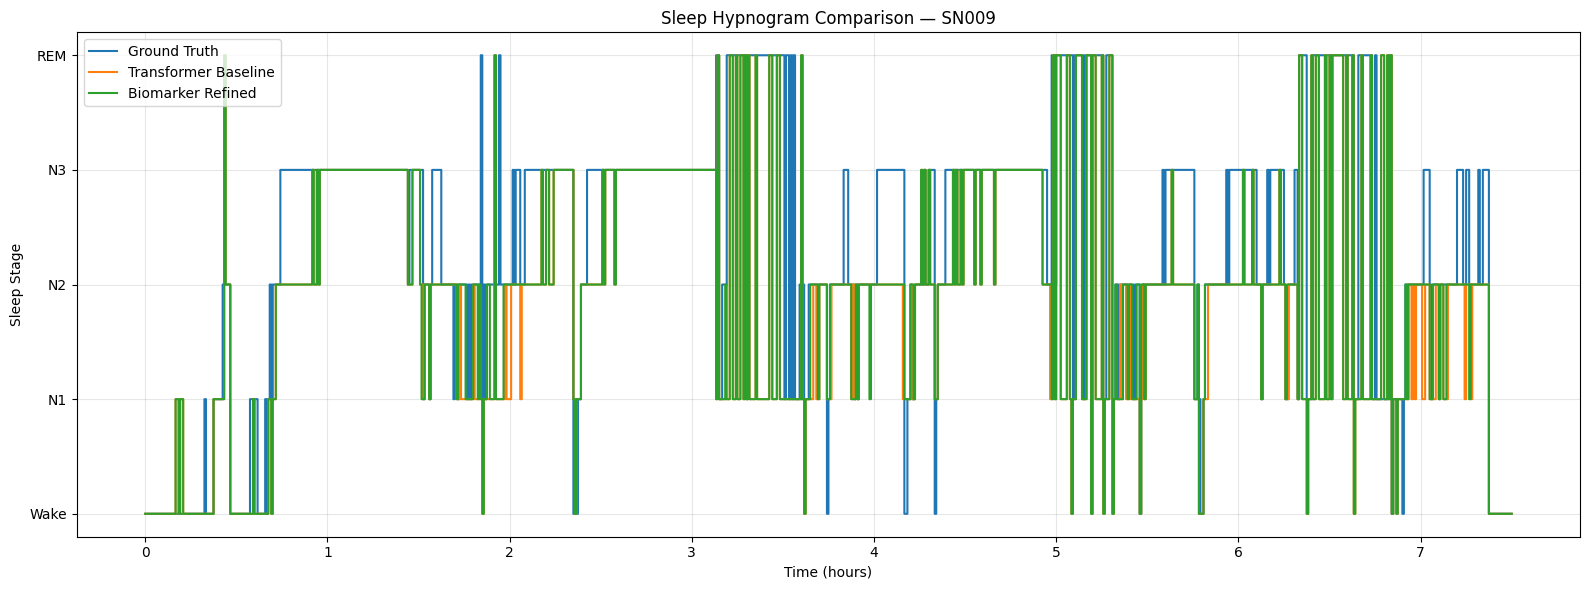

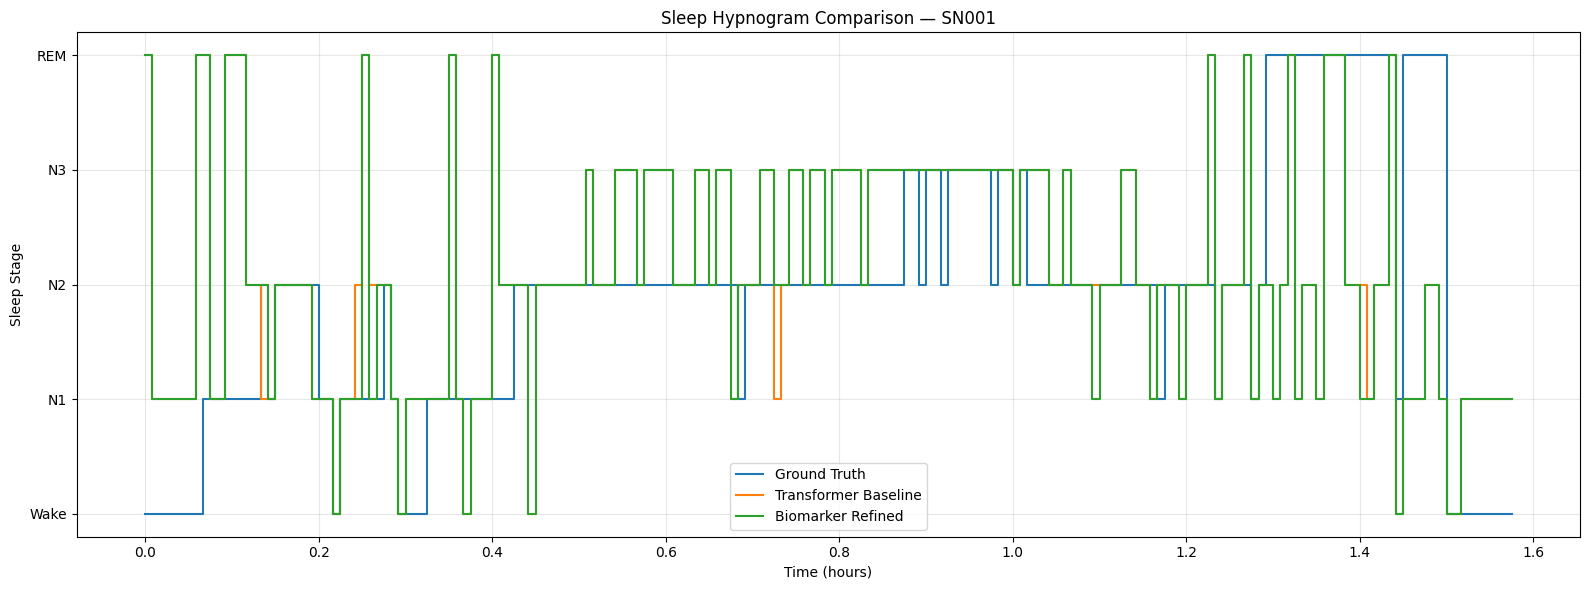

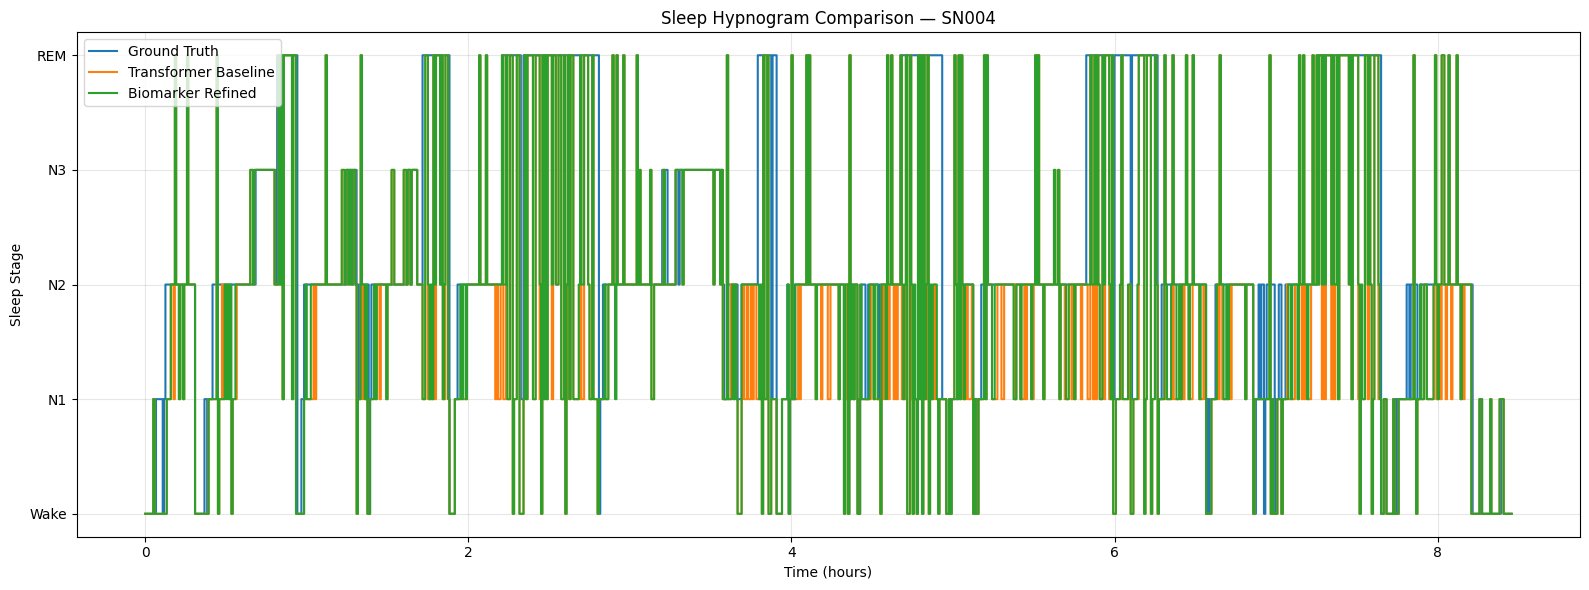

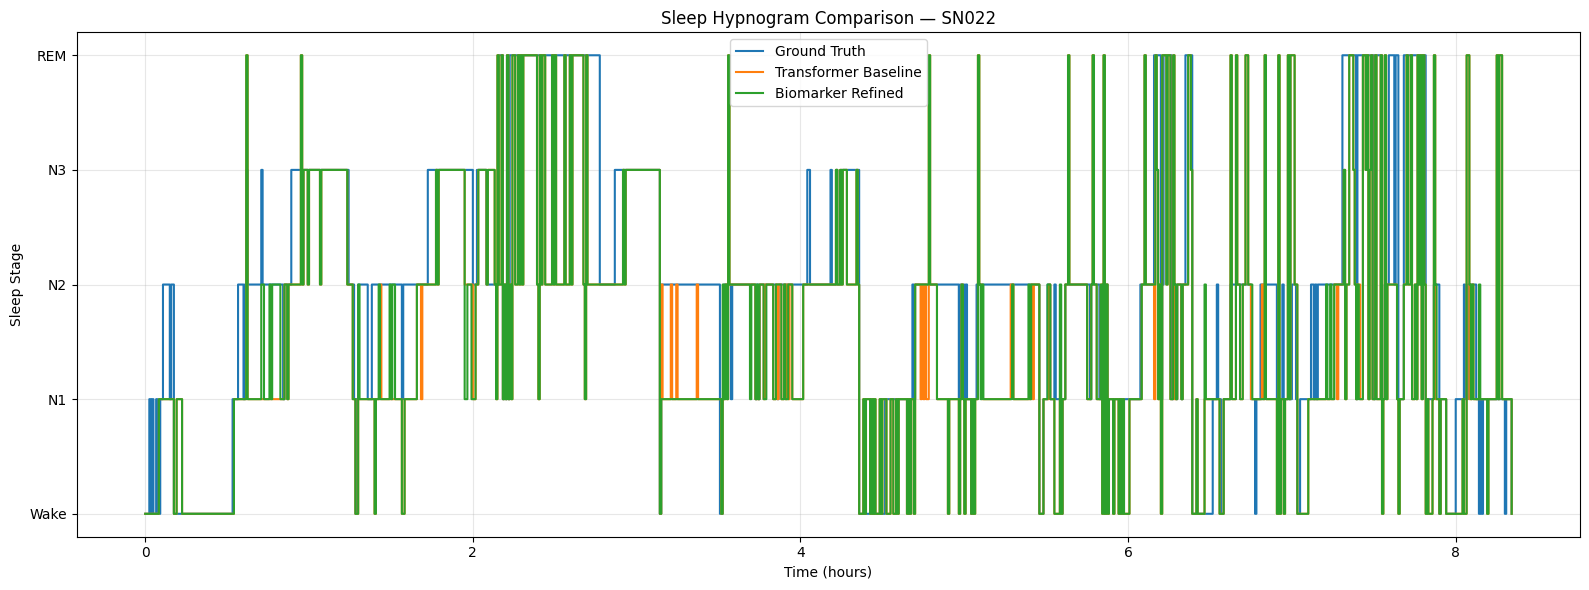

In [ ]:
for subject in test_subjects:
    plot_hypnogram(subject, analysis)

In [ ]:
# ============================================================
# STEP 1 — SLEEP ARCHITECTURE COMPARISON
# ============================================================

architecture_results = []

for subject in baseline_refined_test["subject"].unique():

    subject_data = (
        baseline_refined_test[
            baseline_refined_test["subject"] == subject
        ]
        .sort_values("epoch")
    )

    # --------------------------------------------------------
    # Ground Truth
    # --------------------------------------------------------
    gt_metrics = calculate_sleep_metrics(
        subject_data["true_stage"].values
    )

    gt_metrics["subject"] = subject
    gt_metrics["version"] = "Ground Truth"

    architecture_results.append(gt_metrics)

    # --------------------------------------------------------
    # Original Transformer
    # --------------------------------------------------------
    baseline_metrics = calculate_sleep_metrics(
        subject_data["predicted_stage"].values
    )

    baseline_metrics["subject"] = subject
    baseline_metrics["version"] = "Baseline Transformer"

    architecture_results.append(baseline_metrics)

    # --------------------------------------------------------
    # Biomarker-refined Transformer
    # --------------------------------------------------------
    refined_metrics = calculate_sleep_metrics(
        subject_data["refined_stage"].values
    )

    refined_metrics["subject"] = subject
    refined_metrics["version"] = "Biomarker Refined"

    architecture_results.append(refined_metrics)


# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

architecture_df = pd.DataFrame(architecture_results)

# Put subject/version first
cols = [
    "subject",
    "version",
    "recording_minutes",
    "TST_minutes",
    "sleep_efficiency_percent",
    "sleep_onset_latency_min",
    "WASO_minutes",
    "REM_latency_min",
    "N1_percent",
    "N2_percent",
    "N3_percent",
    "REM_percent",
    "awakenings",
    "stage_transitions",
    "fragmentation_index"
]

architecture_df = architecture_df[cols]

# Sort
architecture_df = architecture_df.sort_values(
    ["subject", "version"]
).reset_index(drop=True)

print("================================================")
print("STEP 1 — SLEEP ARCHITECTURE RESULTS")
print("================================================")

display(architecture_df.round(2))

STEP 1 — SLEEP ARCHITECTURE RESULTS


,subject,version,recording_minutes,TST_minutes,sleep_efficiency_percent,sleep_onset_latency_min,WASO_minutes,REM_latency_min,N1_percent,N2_percent,N3_percent,REM_percent,awakenings,stage_transitions,fragmentation_index
0,SN001,Baseline Transformer,95.0,91.5,96.32,0.0,3.5,0.0,26.23,38.25,26.78,8.74,6,79,51.80
1,SN001,Biomarker Refined,95.0,91.5,96.32,0.0,3.5,0.0,27.32,37.16,26.78,8.74,6,80,52.46
2,SN001,Ground Truth,95.0,83.5,87.89,4.0,7.5,73.5,20.96,56.89,7.78,14.37,3,34,24.43
3,SN004,Baseline Transformer,508.0,442.5,87.11,3.0,62.5,8.0,40.45,35.14,8.02,16.38,52,457,61.97
4,SN004,Biomarker Refined,508.0,442.5,87.11,3.0,62.5,8.0,27.46,48.14,8.02,16.38,52,440,59.66
5,SN004,Ground Truth,508.0,468.0,92.13,3.0,37.0,46.0,9.72,57.05,6.84,26.39,29,135,17.31
6,SN009,Baseline Transformer,450.5,402.0,89.23,10.0,38.5,16.0,27.86,38.68,26.49,6.97,19,211,31.49
7,SN009,Biomarker Refined,450.5,402.0,89.23,10.0,38.5,16.0,23.38,43.16,26.49,6.97,19,210,31.34
8,SN009,Ground Truth,450.5,405.0,89.90,19.5,26.0,91.0,10.99,26.91,46.79,15.31,13,156,23.11
9,SN022,Baseline Transformer,501.0,428.5,85.53,5.0,67.5,32.0,47.84,31.04,11.55,9.57,51,318,44.53


In [ ]:
print("BIOMARKER FEATURES:")
print(BIOMARKER_FEATURES)

print("\nTEST FEATURES SHAPE:")
print(test_features.shape)

print("\nTEST FEATURES COLUMNS:")
print(test_features.columns.tolist())

print("\nTEST FEATURES SAMPLE:")
display(test_features.head())

BIOMARKER FEATURES:
['delta_relative', 'theta_relative', 'alpha_relative', 'sigma_relative', 'beta_relative', 'sigma_delta_ratio', 'theta_delta_ratio', 'alpha_delta_ratio', 'beta_delta_ratio']

TEST FEATURES SHAPE:
(3109, 17)

TEST FEATURES COLUMNS:
['subject', 'epoch', 'true_stage', 'delta_power', 'theta_power', 'alpha_power', 'sigma_power', 'beta_power', 'delta_relative', 'theta_relative', 'alpha_relative', 'sigma_relative', 'beta_relative', 'sigma_delta_ratio', 'theta_delta_ratio', 'alpha_delta_ratio', 'beta_delta_ratio']

TEST FEATURES SAMPLE:


,subject,epoch,true_stage,delta_power,theta_power,alpha_power,sigma_power,beta_power,delta_relative,theta_relative,alpha_relative,sigma_relative,beta_relative,sigma_delta_ratio,theta_delta_ratio,alpha_delta_ratio,beta_delta_ratio
0,SN009,0,0,0.372774,0.045547,0.039411,0.034996,0.094766,0.621821,0.075976,0.065742,0.058377,0.158078,0.093881,0.122183,0.105725,0.254218
1,SN009,1,0,0.377808,0.020761,0.020592,0.018029,0.109698,0.682966,0.037530,0.037224,0.032592,0.198302,0.047721,0.054951,0.054503,0.290354
2,SN009,2,0,0.400619,0.032340,0.037766,0.022945,0.073373,0.691291,0.055804,0.065167,0.039593,0.126609,0.057274,0.080724,0.094269,0.183149
3,SN009,3,0,0.327449,0.022126,0.060680,0.029785,0.118580,0.572847,0.038708,0.106155,0.052107,0.207446,0.090961,0.067570,0.185311,0.362131
4,SN009,4,0,0.394117,0.030656,0.038961,0.025447,0.073150,0.691872,0.053817,0.068396,0.044672,0.128414,0.064566,0.077784,0.098856,0.185604


In [ ]:
# ============================================================
# STEP 2 — MASTER SLEEP-HEALTH FEATURE MATRIX
# ============================================================

# ------------------------------------------------------------
# 1. Aggregate EEG biomarkers per subject/night
# ------------------------------------------------------------

test_biomarker_subject = (
    test_features
    .groupby("subject")[BIOMARKER_FEATURES]
    .mean()
    .reset_index()
)

print("EEG biomarker subject-level features:")
display(test_biomarker_subject.round(4))


# ------------------------------------------------------------
# 2. Select the BIOMARKER-REFINED sleep architecture
# ------------------------------------------------------------

refined_architecture = architecture_df[
    architecture_df["version"] == "Biomarker Refined"
].copy()

# Remove version because this will now be our final
# estimated sleep-health feature table
refined_architecture = refined_architecture.drop(
    columns=["version"]
)


# ------------------------------------------------------------
# 3. Merge sleep architecture + EEG biomarkers
# ------------------------------------------------------------

master_sleep_health_features = refined_architecture.merge(
    test_biomarker_subject,
    on="subject",
    how="inner"
)


# ------------------------------------------------------------
# 4. Display final feature matrix
# ------------------------------------------------------------

print("\n================================================")
print("STEP 2 — MASTER SLEEP-HEALTH FEATURE MATRIX")
print("================================================")

print(
    f"Shape: {master_sleep_health_features.shape}"
)

display(
    master_sleep_health_features.round(4)
)

EEG biomarker subject-level features:


,subject,delta_relative,theta_relative,alpha_relative,sigma_relative,beta_relative,sigma_delta_ratio,theta_delta_ratio,alpha_delta_ratio,beta_delta_ratio
0,SN001,0.6749,0.1201,0.0911,0.0420,0.0451,0.0652,0.1827,0.1448,0.0723
1,SN004,0.6632,0.1348,0.0703,0.0430,0.0611,0.0732,0.2174,0.1197,0.1098
2,SN009,0.6323,0.1284,0.0863,0.0562,0.0682,0.1067,0.2208,0.1727,0.1522
3,SN022,0.6826,0.1565,0.0384,0.0254,0.0781,0.0448,0.2513,0.0654,0.1398



STEP 2 — MASTER SLEEP-HEALTH FEATURE MATRIX
Shape: (4, 23)


,subject,recording_minutes,TST_minutes,sleep_efficiency_percent,sleep_onset_latency_min,WASO_minutes,REM_latency_min,N1_percent,N2_percent,N3_percent,...,fragmentation_index,delta_relative,theta_relative,alpha_relative,sigma_relative,beta_relative,sigma_delta_ratio,theta_delta_ratio,alpha_delta_ratio,beta_delta_ratio
0,SN001,95.0,91.5,96.3158,0.0,3.5,0.0,27.3224,37.1585,26.7760,...,52.4590,0.6749,0.1201,0.0911,0.0420,0.0451,0.0652,0.1827,0.1448,0.0723
1,SN004,508.0,442.5,87.1063,3.0,62.5,8.0,27.4576,48.1356,8.0226,...,59.6610,0.6632,0.1348,0.0703,0.0430,0.0611,0.0732,0.2174,0.1197,0.1098
2,SN009,450.5,402.0,89.2342,10.0,38.5,16.0,23.3831,43.1592,26.4925,...,31.3433,0.6323,0.1284,0.0863,0.0562,0.0682,0.1067,0.2208,0.1727,0.1522
3,SN022,501.0,428.5,85.5289,5.0,67.5,32.0,45.1575,33.7223,11.5519,...,45.3676,0.6826,0.1565,0.0384,0.0254,0.0781,0.0448,0.2513,0.0654,0.1398


In [ ]:
# ============================================================
# STEP 3A — BIOMARKER REFINEMENT FOR TRAINING SUBJECTS
# ============================================================

baseline_refined_train = baseline_train.copy()

# ------------------------------------------------------------
# Identify epochs where Transformer predicted N1 or N2
# ------------------------------------------------------------

train_candidate_mask = baseline_refined_train[
    "predicted_stage"
].isin([N1_LABEL, N2_LABEL])

train_candidates = baseline_refined_train[
    train_candidate_mask
].copy()

print("========================================")
print("TRAIN N1/N2 CANDIDATES")
print("========================================")

print(
    f"Total Transformer N1/N2 candidates: "
    f"{len(train_candidates)}"
)

# ------------------------------------------------------------
# Get biomarker features for these exact epochs
# ------------------------------------------------------------

train_candidate_features = train_candidates[
    ["subject", "epoch"]
].merge(
    train_features[
        ["subject", "epoch"] + BIOMARKER_FEATURES
    ],
    on=["subject", "epoch"],
    how="left"
)

# Sanity checks
assert len(train_candidate_features) == len(
    train_candidates
)

assert not train_candidate_features[
    BIOMARKER_FEATURES
].isnull().any().any()

# ------------------------------------------------------------
# Biomarker refinement prediction
# ------------------------------------------------------------

X_train_refine = train_candidate_features[
    BIOMARKER_FEATURES
].values.astype(np.float32)

refined_binary = refinement_model.predict(
    X_train_refine
)

# Binary mapping:
# 0 -> N1
# 1 -> N2

refined_stage = np.where(
    refined_binary == 0,
    N1_LABEL,
    N2_LABEL
)

# ------------------------------------------------------------
# Replace ONLY N1/N2 Transformer predictions
# ------------------------------------------------------------

baseline_refined_train.loc[
    train_candidate_mask,
    "refined_stage"
] = refined_stage

# Everything outside N1/N2 candidates remains unchanged
baseline_refined_train.loc[
    ~train_candidate_mask,
    "refined_stage"
] = baseline_refined_train.loc[
    ~train_candidate_mask,
    "predicted_stage"
]

baseline_refined_train[
    "refined_stage"
] = baseline_refined_train[
    "refined_stage"
].astype(int)

print("\nBiomarker-assisted TRAIN predictions generated.")

print("\nPrediction counts:")
print(
    baseline_refined_train[
        "refined_stage"
    ].map(dict(enumerate(CLASS_NAMES))).value_counts()
)

TRAIN N1/N2 CANDIDATES
Total Transformer N1/N2 candidates: 7408

Biomarker-assisted TRAIN predictions generated.

Prediction counts:
refined_stage
N2     4916
W      3126
N3     3105
N1     2492
REM    1577
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 3B — TRAINING SLEEP-ARCHITECTURE REFERENCE
# ============================================================

train_architecture_results = []

for subject in baseline_refined_train["subject"].unique():

    subject_data = (
        baseline_refined_train[
            baseline_refined_train["subject"] == subject
        ]
        .sort_values("epoch")
    )

    metrics = calculate_sleep_metrics(
        subject_data["refined_stage"].values
    )

    metrics["subject"] = subject

    train_architecture_results.append(metrics)


# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

train_architecture_df = pd.DataFrame(
    train_architecture_results
)

# Put subject first
cols = [
    "subject",
    "recording_minutes",
    "TST_minutes",
    "sleep_efficiency_percent",
    "sleep_onset_latency_min",
    "WASO_minutes",
    "REM_latency_min",
    "N1_percent",
    "N2_percent",
    "N3_percent",
    "REM_percent",
    "awakenings",
    "stage_transitions",
    "fragmentation_index"
]

train_architecture_df = train_architecture_df[
    cols
]

train_architecture_df = (
    train_architecture_df
    .sort_values("subject")
    .reset_index(drop=True)
)

print("================================================")
print("TRAINING SLEEP-ARCHITECTURE REFERENCE")
print("================================================")

print(
    "Number of subjects:",
    len(train_architecture_df)
)

display(
    train_architecture_df.round(2)
)

TRAINING SLEEP-ARCHITECTURE REFERENCE
Number of subjects: 16


,subject,recording_minutes,TST_minutes,sleep_efficiency_percent,sleep_onset_latency_min,WASO_minutes,REM_latency_min,N1_percent,N2_percent,N3_percent,REM_percent,awakenings,stage_transitions,fragmentation_index
0,SN002,428.0,374.0,87.38,4.0,50.0,109.5,11.90,37.97,31.15,18.98,34,228,36.58
1,SN003,477.0,285.0,59.75,1.5,190.5,263.5,18.25,32.81,28.60,20.35,51,239,50.32
2,SN006,433.0,375.5,86.72,5.5,52.0,7.5,15.05,56.06,23.44,5.46,34,257,41.07
3,SN007,517.0,488.5,94.49,9.0,19.5,127.5,17.20,50.05,20.37,12.38,10,288,35.37
4,SN010,462.0,352.5,76.30,32.0,77.5,183.5,18.72,52.77,15.60,12.91,37,220,37.45
5,SN011,570.5,514.0,90.10,3.5,53.0,513.5,39.49,37.55,21.40,1.56,39,481,56.15
6,SN012,468.5,366.5,78.23,15.0,87.0,0.5,8.19,36.02,39.29,16.51,35,270,44.20
7,SN013,502.0,454.0,90.44,12.0,36.0,18.5,23.57,26.10,31.83,18.50,28,302,39.91
8,SN015,433.5,273.0,62.98,13.5,147.0,0.5,39.19,23.63,23.44,13.74,53,268,58.90
9,SN016,544.0,530.0,97.43,3.5,10.5,30.5,7.08,40.09,34.34,18.49,4,259,29.32


In [ ]:
# ============================================================
# STEP 3C — COMPLETE TRAINING REFERENCE FEATURE MATRIX
# ============================================================

# ------------------------------------------------------------
# 1. Aggregate EEG biomarkers per training subject
# ------------------------------------------------------------

train_biomarker_subject = (
    train_features
    .groupby("subject")[BIOMARKER_FEATURES]
    .mean()
    .reset_index()
)

print("Training EEG biomarker features:")
display(train_biomarker_subject.round(4))


# ------------------------------------------------------------
# 2. Merge architecture + EEG biomarkers
# ------------------------------------------------------------

train_reference_features = train_architecture_df.merge(
    train_biomarker_subject,
    on="subject",
    how="inner"
)


# ------------------------------------------------------------
# 3. Sanity checks
# ------------------------------------------------------------

assert len(train_reference_features) == 16

assert (
    train_reference_features["subject"].nunique()
    == 16
)

assert not train_reference_features[
    BIOMARKER_FEATURES
].isnull().any().any()


# ------------------------------------------------------------
# 4. Display
# ------------------------------------------------------------

print("\n================================================")
print("STEP 3 — HMC TRAINING REFERENCE MATRIX")
print("================================================")

print(
    "Shape:",
    train_reference_features.shape
)

display(
    train_reference_features.round(4)
)

Training EEG biomarker features:


,subject,delta_relative,theta_relative,alpha_relative,sigma_relative,beta_relative,sigma_delta_ratio,theta_delta_ratio,alpha_delta_ratio,beta_delta_ratio
0,SN002,0.7123,0.1219,0.0602,0.0378,0.0442,0.0591,0.1849,0.0949,0.0728
1,SN003,0.7307,0.1095,0.0537,0.0284,0.0530,0.0444,0.1647,0.0848,0.0828
2,SN006,0.7302,0.1164,0.0595,0.0322,0.0420,0.0525,0.1765,0.0962,0.0689
3,SN007,0.6896,0.1350,0.0782,0.0357,0.0372,0.0594,0.2238,0.1551,0.0683
4,SN010,0.6584,0.1308,0.0788,0.0353,0.0700,0.0634,0.2098,0.1505,0.1380
5,SN011,0.5506,0.1828,0.1674,0.0294,0.0357,0.0697,0.4040,0.4223,0.0898
6,SN012,0.7496,0.0923,0.0828,0.0208,0.0350,0.0346,0.1435,0.1815,0.0643
7,SN013,0.6947,0.1187,0.0801,0.0347,0.0483,0.0589,0.1895,0.1370,0.0847
8,SN015,0.6199,0.1107,0.0806,0.0470,0.1152,0.0883,0.1949,0.1450,0.2365
9,SN016,0.7604,0.1293,0.0407,0.0212,0.0261,0.0318,0.1849,0.0610,0.0419



STEP 3 — HMC TRAINING REFERENCE MATRIX
Shape: (16, 23)


,subject,recording_minutes,TST_minutes,sleep_efficiency_percent,sleep_onset_latency_min,WASO_minutes,REM_latency_min,N1_percent,N2_percent,N3_percent,...,fragmentation_index,delta_relative,theta_relative,alpha_relative,sigma_relative,beta_relative,sigma_delta_ratio,theta_delta_ratio,alpha_delta_ratio,beta_delta_ratio
0,SN002,428.0,374.0,87.3832,4.0,50.0,109.5,11.8984,37.9679,31.1497,...,36.5775,0.7123,0.1219,0.0602,0.0378,0.0442,0.0591,0.1849,0.0949,0.0728
1,SN003,477.0,285.0,59.7484,1.5,190.5,263.5,18.2456,32.8070,28.5965,...,50.3158,0.7307,0.1095,0.0537,0.0284,0.0530,0.0444,0.1647,0.0848,0.0828
2,SN006,433.0,375.5,86.7206,5.5,52.0,7.5,15.0466,56.0586,23.4354,...,41.0652,0.7302,0.1164,0.0595,0.0322,0.0420,0.0525,0.1765,0.0962,0.0689
3,SN007,517.0,488.5,94.4874,9.0,19.5,127.5,17.1955,50.0512,20.3685,...,35.3736,0.6896,0.1350,0.0782,0.0357,0.0372,0.0594,0.2238,0.1551,0.0683
4,SN010,462.0,352.5,76.2987,32.0,77.5,183.5,18.7234,52.7660,15.6028,...,37.4468,0.6584,0.1308,0.0788,0.0353,0.0700,0.0634,0.2098,0.1505,0.1380
5,SN011,570.5,514.0,90.0964,3.5,53.0,513.5,39.4942,37.5486,21.4008,...,56.1479,0.5506,0.1828,0.1674,0.0294,0.0357,0.0697,0.4040,0.4223,0.0898
6,SN012,468.5,366.5,78.2284,15.0,87.0,0.5,8.1855,36.0164,39.2906,...,44.2019,0.7496,0.0923,0.0828,0.0208,0.0350,0.0346,0.1435,0.1815,0.0643
7,SN013,502.0,454.0,90.4382,12.0,36.0,18.5,23.5683,26.1013,31.8282,...,39.9119,0.6947,0.1187,0.0801,0.0347,0.0483,0.0589,0.1895,0.1370,0.0847
8,SN015,433.5,273.0,62.9758,13.5,147.0,0.5,39.1941,23.6264,23.4432,...,58.9011,0.6199,0.1107,0.0806,0.0470,0.1152,0.0883,0.1949,0.1450,0.2365
9,SN016,544.0,530.0,97.4265,3.5,10.5,30.5,7.0755,40.0943,34.3396,...,29.3208,0.7604,0.1293,0.0407,0.0212,0.0261,0.0318,0.1849,0.0610,0.0419


In [ ]:
# ============================================================
# STEP 3D — TRAINING REFERENCE DISTRIBUTION
# ============================================================

# ------------------------------------------------------------
# Feature columns
# ------------------------------------------------------------

REFERENCE_FEATURES = [
    col for col in train_reference_features.columns
    if col != "subject"
]

# ------------------------------------------------------------
# Calculate reference statistics
# ------------------------------------------------------------

reference_stats = pd.DataFrame({
    "feature": REFERENCE_FEATURES,

    "mean": [
        train_reference_features[col].mean()
        for col in REFERENCE_FEATURES
    ],

    "std": [
        train_reference_features[col].std(ddof=1)
        for col in REFERENCE_FEATURES
    ],

    "median": [
        train_reference_features[col].median()
        for col in REFERENCE_FEATURES
    ],

    "p10": [
        train_reference_features[col].quantile(0.10)
        for col in REFERENCE_FEATURES
    ],

    "p90": [
        train_reference_features[col].quantile(0.90)
        for col in REFERENCE_FEATURES
    ]
})

# ------------------------------------------------------------
# Check for zero standard deviation
# ------------------------------------------------------------

zero_std_features = reference_stats[
    reference_stats["std"] == 0
]["feature"].tolist()

print("================================================")
print("STEP 3D — HMC TRAINING REFERENCE DISTRIBUTION")
print("================================================")

print(
    "Number of features:",
    len(REFERENCE_FEATURES)
)

print(
    "Zero-SD features:",
    zero_std_features
)

display(
    reference_stats.round(4)
)

STEP 3D — HMC TRAINING REFERENCE DISTRIBUTION
Number of features: 22
Zero-SD features: []


,feature,mean,std,median,p10,p90
0,recording_minutes,475.5000,52.0813,471.2500,424.0000,550.5000
1,TST_minutes,377.8125,98.5261,370.2500,256.2500,512.5000
2,sleep_efficiency_percent,78.5980,14.1666,82.4724,59.1599,93.1144
3,sleep_onset_latency_min,9.6250,7.2099,8.2500,3.5000,14.2500
4,WASO_minutes,88.0625,61.0873,66.5000,27.7500,179.2500
5,REM_latency_min,127.7500,134.5230,110.7500,4.0000,275.0000
6,N1_percent,20.3309,10.5872,18.4724,7.6305,36.5770
7,N2_percent,40.4844,14.0341,37.7583,24.6976,57.2590
8,N3_percent,26.2199,11.3875,23.5611,15.5519,40.9868
9,REM_percent,12.9649,5.7078,13.2628,5.7999,19.4235


In [ ]:
# ============================================================
# STEP 3E — TEST SUBJECT DEVIATION PROFILES
# ============================================================

# ------------------------------------------------------------
# Features used for sleep-health deviation analysis
# ------------------------------------------------------------

DEVIATION_FEATURES = [
    f for f in REFERENCE_FEATURES
    if f != "recording_minutes"
]

# ------------------------------------------------------------
# Calculate deviations
# ------------------------------------------------------------

deviation_rows = []

for _, subject_row in master_sleep_health_features.iterrows():

    subject = subject_row["subject"]

    row = {
        "subject": subject
    }

    for feature in DEVIATION_FEATURES:

        x = subject_row[feature]

        ref = reference_stats[
            reference_stats["feature"] == feature
        ].iloc[0]

        mean = ref["mean"]
        std = ref["std"]
        p10 = ref["p10"]
        p90 = ref["p90"]

        # Z-score
        z = (x - mean) / std

        # Percentile-region flag
        if x < p10:
            region = "Below_P10"
        elif x > p90:
            region = "Above_P90"
        else:
            region = "Within_P10_P90"

        row[f"{feature}_value"] = x
        row[f"{feature}_z"] = z
        row[f"{feature}_region"] = region

    deviation_rows.append(row)


test_deviation_profiles = pd.DataFrame(
    deviation_rows
)

print("================================================")
print("STEP 3E — TEST DEVIATION PROFILES")
print("================================================")

print(
    "Subjects:",
    len(test_deviation_profiles)
)

print(
    "Deviation features:",
    len(DEVIATION_FEATURES)
)

display(
    test_deviation_profiles.round(3)
)

STEP 3E — TEST DEVIATION PROFILES
Subjects: 4
Deviation features: 21


,subject,TST_minutes_value,TST_minutes_z,TST_minutes_region,sleep_efficiency_percent_value,sleep_efficiency_percent_z,sleep_efficiency_percent_region,sleep_onset_latency_min_value,sleep_onset_latency_min_z,sleep_onset_latency_min_region,...,sigma_delta_ratio_region,theta_delta_ratio_value,theta_delta_ratio_z,theta_delta_ratio_region,alpha_delta_ratio_value,alpha_delta_ratio_z,alpha_delta_ratio_region,beta_delta_ratio_value,beta_delta_ratio_z,beta_delta_ratio_region
0,SN001,91.5,-2.906,Below_P10,96.316,1.251,Above_P90,0.0,-1.335,Below_P10,...,Within_P10_P90,0.183,-0.602,Within_P10_P90,0.145,-0.315,Within_P10_P90,0.072,-0.593,Within_P10_P90
1,SN004,442.5,0.657,Within_P10_P90,87.106,0.601,Within_P10_P90,3.0,-0.919,Below_P10,...,Within_P10_P90,0.217,-0.090,Within_P10_P90,0.120,-0.462,Within_P10_P90,0.110,-0.070,Within_P10_P90
2,SN009,402.0,0.245,Within_P10_P90,89.234,0.751,Within_P10_P90,10.0,0.052,Within_P10_P90,...,Above_P90,0.221,-0.040,Within_P10_P90,0.173,-0.151,Within_P10_P90,0.152,0.524,Within_P10_P90
3,SN022,428.5,0.514,Within_P10_P90,85.529,0.489,Within_P10_P90,5.0,-0.641,Within_P10_P90,...,Within_P10_P90,0.251,0.411,Within_P10_P90,0.065,-0.781,Below_P10,0.140,0.350,Within_P10_P90


In [ ]:
# ============================================================
# STEP 4A — SIMPLE SLEEP-HEALTH ABNORMALITY FLAGS
# ============================================================

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def get_region(subject_row, feature):
    return subject_row[f"{feature}_region"]


def region_to_flag(region):
    if region == "Below_P10":
        return "LOW"
    elif region == "Above_P90":
        return "HIGH"
    else:
        return "NORMAL"


# ------------------------------------------------------------
# Define the four sleep-health domains
# ------------------------------------------------------------

DOMAIN_FEATURES = {

    "Sleep_Duration": [
        "TST_minutes"
    ],

    "Sleep_Continuity": [
        "sleep_efficiency_percent",
        "WASO_minutes",
        "awakenings",
        "fragmentation_index"
    ],

    "Sleep_Initiation": [
        "sleep_onset_latency_min"
    ],

    "Sleep_Architecture": [
        "N1_percent",
        "N2_percent",
        "N3_percent",
        "REM_percent"
    ]
}


# ------------------------------------------------------------
# Create domain-level profiles
# ------------------------------------------------------------

domain_profiles = []

for _, row in test_deviation_profiles.iterrows():

    subject = row["subject"]

    profile = {
        "subject": subject
    }

    # --------------------------------------------------------
    # Process each domain
    # --------------------------------------------------------

    for domain, features in DOMAIN_FEATURES.items():

        flags = []

        for feature in features:

            region = get_region(row, feature)
            flag = region_to_flag(region)

            flags.append(flag)

            # Store individual feature flag
            profile[
                f"{feature}_flag"
            ] = flag

        # ----------------------------------------------------
        # Domain summary
        #
        # If any feature is outside P10-P90,
        # mark the domain as DEVIATED.
        # ----------------------------------------------------

        if "LOW" in flags or "HIGH" in flags:
            domain_status = "DEVIATED"
        else:
            domain_status = "WITHIN_REFERENCE"

        profile[
            f"{domain}_status"
        ] = domain_status

    domain_profiles.append(profile)


# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

domain_profile_df = pd.DataFrame(
    domain_profiles
)

print("================================================")
print("STEP 4A — SLEEP-HEALTH DOMAIN PROFILE")
print("================================================")

display(domain_profile_df)

STEP 4A — SLEEP-HEALTH DOMAIN PROFILE


,subject,TST_minutes_flag,Sleep_Duration_status,sleep_efficiency_percent_flag,WASO_minutes_flag,awakenings_flag,fragmentation_index_flag,Sleep_Continuity_status,sleep_onset_latency_min_flag,Sleep_Initiation_status,N1_percent_flag,N2_percent_flag,N3_percent_flag,REM_percent_flag,Sleep_Architecture_status
0,SN001,LOW,DEVIATED,HIGH,LOW,LOW,NORMAL,DEVIATED,LOW,DEVIATED,NORMAL,NORMAL,NORMAL,NORMAL,WITHIN_REFERENCE
1,SN004,NORMAL,WITHIN_REFERENCE,NORMAL,NORMAL,HIGH,HIGH,DEVIATED,LOW,DEVIATED,NORMAL,NORMAL,LOW,NORMAL,DEVIATED
2,SN009,NORMAL,WITHIN_REFERENCE,NORMAL,NORMAL,NORMAL,LOW,DEVIATED,NORMAL,WITHIN_REFERENCE,NORMAL,NORMAL,NORMAL,NORMAL,WITHIN_REFERENCE
3,SN022,NORMAL,WITHIN_REFERENCE,NORMAL,NORMAL,HIGH,NORMAL,DEVIATED,NORMAL,WITHIN_REFERENCE,HIGH,NORMAL,LOW,NORMAL,DEVIATED


In [ ]:
# ============================================================
# STEP 5 — SLEEP-HEALTH DEVIATION PROFILE
# ============================================================

DOMAIN_COLUMNS = [
    "Sleep_Duration_status",
    "Sleep_Continuity_status",
    "Sleep_Initiation_status",
    "Sleep_Architecture_status"
]


def classify_deviation_profile(row):

    deviated_domains = sum(
        row[col] == "DEVIATED"
        for col in DOMAIN_COLUMNS
    )

    if deviated_domains == 0:
        return "Within Reference"
    elif deviated_domains == 1:
        return "Mild Deviation"
    elif deviated_domains == 2:
        return "Moderate Deviation"
    else:
        return "High Deviation"


# ------------------------------------------------------------
# Create final profile
# ------------------------------------------------------------

sleep_health_profile = domain_profile_df.copy()

sleep_health_profile[
    "deviated_domain_count"
] = sleep_health_profile[
    DOMAIN_COLUMNS
].apply(
    lambda row: sum(
        value == "DEVIATED"
        for value in row
    ),
    axis=1
)

sleep_health_profile[
    "sleep_health_deviation_profile"
] = sleep_health_profile.apply(
    classify_deviation_profile,
    axis=1
)


# ------------------------------------------------------------
# Add methodological note
# ------------------------------------------------------------

sleep_health_profile[
    "interpretation_note"
] = (
    "Profile is based on deviation from the current "
    "HMC training-reference dataset. It is not a "
    "clinically validated or clinically approved "
    "medical risk assessment."
)


# ------------------------------------------------------------
# Display final output
# ------------------------------------------------------------

print("================================================")
print("STEP 5 — SLEEP-HEALTH DEVIATION PROFILE")
print("================================================")

display(
    sleep_health_profile[
        [
            "subject",
            "Sleep_Duration_status",
            "Sleep_Continuity_status",
            "Sleep_Initiation_status",
            "Sleep_Architecture_status",
            "deviated_domain_count",
            "sleep_health_deviation_profile",
            "interpretation_note"
        ]
    ]
)

STEP 5 — SLEEP-HEALTH DEVIATION PROFILE


,subject,Sleep_Duration_status,Sleep_Continuity_status,Sleep_Initiation_status,Sleep_Architecture_status,deviated_domain_count,sleep_health_deviation_profile,interpretation_note
0,SN001,DEVIATED,DEVIATED,DEVIATED,WITHIN_REFERENCE,3,High Deviation,Profile is based on deviation from the current...
1,SN004,WITHIN_REFERENCE,DEVIATED,DEVIATED,DEVIATED,3,High Deviation,Profile is based on deviation from the current...
2,SN009,WITHIN_REFERENCE,DEVIATED,WITHIN_REFERENCE,WITHIN_REFERENCE,1,Mild Deviation,Profile is based on deviation from the current...
3,SN022,WITHIN_REFERENCE,DEVIATED,WITHIN_REFERENCE,DEVIATED,2,Moderate Deviation,Profile is based on deviation from the current...


In [ ]:
# ============================================================
# STEP 6 — USER-FACING SLEEP-HEALTH DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets


# ============================================================
# 1. CHECK REQUIRED DATA
# ============================================================

required_objects = [
    "sleep_health_profile",
    "domain_profile_df",
    "test_deviation_profiles",
    "master_sleep_health_features"
]

missing = [x for x in required_objects if x not in globals()]

if missing:
    raise NameError(
        f"Missing required objects: {missing}. "
        "Please run Steps 2–5 first."
    )


# ============================================================
# 2. SUBJECT LIST
# ============================================================

subjects = sorted(
    sleep_health_profile["subject"].astype(str).unique()
)


# ============================================================
# 3. HELPER FUNCTION
# ============================================================

def get_subject_profile(subject):

    profile = sleep_health_profile[
        sleep_health_profile["subject"].astype(str) == subject
    ].iloc[0]

    features = master_sleep_health_features[
        master_sleep_health_features["subject"].astype(str) == subject
    ].iloc[0]

    return profile, features


# ============================================================
# 4. DASHBOARD OUTPUT AREA
# ============================================================

# This is the important fix:
# The dropdown is outside this output area.
# Only this area will be cleared and redrawn.

dashboard_output = widgets.Output()


# ============================================================
# 5. DASHBOARD FUNCTION
# ============================================================

def show_dashboard(subject):

    with dashboard_output:

        # Clear ONLY the dashboard
        clear_output(wait=True)

        # ----------------------------------------------------
        # Get subject data
        # ----------------------------------------------------

        profile, features = get_subject_profile(subject)

        overall = profile["sleep_health_deviation_profile"]

        deviated_count = int(
            profile["deviated_domain_count"]
        )


        # ====================================================
        # HEADER
        # ====================================================

        display(HTML(f"""
        <div style="
            background:#f5f7fa;
            padding:25px;
            border-radius:15px;
            margin-bottom:20px;
            font-family:Arial;
        ">

            <h1 style="
                margin:0 0 5px 0;
                color:#111;
            ">
                Sleep Health Profile
            </h1>

            <p style="
                margin:0;
                color:#666;
                font-size:16px;
            ">
                Subject:
                <b>{subject}</b>
            </p>

        </div>
        """))


        # ====================================================
        # OVERALL PROFILE
        # ====================================================

        display(HTML(f"""
        <div style="
            border:1px solid #ddd;
            border-radius:15px;
            padding:20px;
            margin-bottom:20px;
            font-family:Arial;
            background:white;
        ">

            <h2 style="
                margin-top:0;
                color:#111;
            ">
                Overall Profile
            </h2>

            <div style="
                font-size:25px;
                font-weight:bold;
                margin:15px 0;
            ">
                {overall}
            </div>

            <p style="
                color:#555;
                margin-bottom:0;
            ">
                {deviated_count} of 4 sleep-health domains
                show deviation from the current reference dataset.
            </p>

        </div>
        """))


        # ====================================================
        # DOMAIN STATUS
        # ====================================================

        domain_info = [
            (
                "Sleep Duration",
                "Sleep_Duration_status"
            ),
            (
                "Sleep Continuity",
                "Sleep_Continuity_status"
            ),
            (
                "Sleep Initiation",
                "Sleep_Initiation_status"
            ),
            (
                "Sleep Architecture",
                "Sleep_Architecture_status"
            )
        ]


        html = """
        <div style="
            display:grid;
            grid-template-columns:repeat(2,minmax(250px,1fr));
            gap:15px;
            margin-bottom:20px;
            font-family:Arial;
        ">
        """


        for name, column in domain_info:

            status = profile[column]

            if status == "WITHIN_REFERENCE":

                symbol = "✓"
                status_text = "Within reference"

                status_color = "#1f6f43"

            else:

                symbol = "⚠"
                status_text = "Deviation detected"

                status_color = "#9a6700"


            html += f"""
            <div style="
                border:1px solid #ddd;
                border-radius:12px;
                padding:18px;
                background:white;
            ">

                <h3 style="
                    margin-top:0;
                    color:#111;
                ">
                    {name}
                </h3>

                <div style="
                    font-size:18px;
                    font-weight:bold;
                    color:{status_color};
                ">
                    {symbol} {status_text}
                </div>

            </div>
            """


        html += "</div>"


        display(HTML(html))


        # ====================================================
        # SLEEP ARCHITECTURE
        # ====================================================

        stage_features = {

            "N1": "N1_percent",
            "N2": "N2_percent",
            "N3": "N3_percent",
            "REM": "REM_percent"

        }


        stage_values = []


        for stage, feature in stage_features.items():

            try:

                value = float(
                    features[feature]
                )

            except:

                value = np.nan

            stage_values.append(value)


        display(HTML("""
        <div style="
            border:1px solid #ddd;
            border-radius:15px;
            padding:20px;
            margin-bottom:10px;
            font-family:Arial;
            background:white;
        ">

            <h2 style="
                margin-top:0;
            ">
                Sleep Architecture
            </h2>

            <p style="
                color:#666;
                margin-bottom:0;
            ">
                Percentage of total sleep spent in each sleep stage.
            </p>

        </div>
        """))


        # ----------------------------------------------------
        # Architecture chart
        # ----------------------------------------------------

        plt.figure(figsize=(8,4))


        bars = plt.bar(
            list(stage_features.keys()),
            stage_values
        )


        plt.ylabel(
            "Percentage of total sleep (%)"
        )

        plt.xlabel(
            "Sleep stage"
        )

        plt.title(
            f"Sleep Architecture — {subject}"
        )


        valid_values = [
            x for x in stage_values
            if not np.isnan(x)
        ]


        if valid_values:

            plt.ylim(
                0,
                max(
                    60,
                    max(valid_values) + 10
                )
            )


        for bar, value in zip(
            bars,
            stage_values
        ):

            if not np.isnan(value):

                plt.text(

                    bar.get_x()
                    + bar.get_width() / 2,

                    bar.get_height() + 1,

                    f"{value:.1f}%",

                    ha="center"

                )


        plt.tight_layout()

        plt.show()


        # ====================================================
        # BASIC SLEEP METRICS
        # ====================================================

        metric_features = [

            (
                "Total Sleep Time",
                "TST_minutes",
                "min"
            ),

            (
                "Sleep Efficiency",
                "sleep_efficiency_percent",
                "%"
            ),

            (
                "Sleep Onset Latency",
                "sleep_onset_latency_min",
                "min"
            ),

            (
                "WASO",
                "WASO_minutes",
                "min"
            ),

            (
                "REM Latency",
                "REM_latency_min",
                "min"
            ),

            (
                "Awakenings",
                "awakenings",
                ""
            ),

            (
                "Stage Transitions",
                "stage_transitions",
                ""
            )

        ]


        html = """
        <div style="
            border:1px solid #ddd;
            border-radius:15px;
            padding:20px;
            margin-bottom:20px;
            font-family:Arial;
            background:white;
        ">

            <h2 style="
                margin-top:0;
            ">
                Sleep Metrics
            </h2>

            <table style="
                width:100%;
                border-collapse:collapse;
            ">

                <tr>

                    <th style="
                        text-align:left;
                        padding:8px;
                        border-bottom:1px solid #ddd;
                    ">
                        Metric
                    </th>

                    <th style="
                        text-align:right;
                        padding:8px;
                        border-bottom:1px solid #ddd;
                    ">
                        Value
                    </th>

                </tr>
        """


        for name, feature, unit in metric_features:

            try:

                value = features[feature]

            except:

                value = np.nan


            if pd.isna(value):

                value_text = "N/A"

            else:

                value_text = (
                    f"{float(value):.1f} {unit}"
                )


            html += f"""

                <tr>

                    <td style="
                        padding:8px;
                        border-bottom:1px solid #eee;
                    ">
                        {name}
                    </td>

                    <td style="
                        padding:8px;
                        text-align:right;
                        font-weight:bold;
                        border-bottom:1px solid #eee;
                    ">
                        {value_text}
                    </td>

                </tr>

            """


        html += """

            </table>

        </div>
        """


        display(HTML(html))


        # ====================================================
        # EEG BIOMARKERS
        # ====================================================

        biomarker_features = [

            "delta_relative",
            "theta_relative",
            "alpha_relative",
            "sigma_relative",
            "beta_relative",
            "sigma_delta_ratio",
            "theta_delta_ratio",
            "alpha_delta_ratio",
            "beta_delta_ratio"

        ]


        biomarker_labels = [

            "Delta relative power",
            "Theta relative power",
            "Alpha relative power",
            "Sigma relative power",
            "Beta relative power",
            "Sigma / Delta ratio",
            "Theta / Delta ratio",
            "Alpha / Delta ratio",
            "Beta / Delta ratio"

        ]


        display(HTML("""
        <div style="
            border:1px solid #ddd;
            border-radius:15px;
            padding:20px;
            margin-bottom:10px;
            font-family:Arial;
            background:white;
        ">

            <h2 style="
                margin-top:0;
            ">
                EEG Biomarker Profile
            </h2>

            <p style="
                color:#666;
                margin-bottom:0;
            ">
                Spectral features extracted from the EEG signal.
                These are presented descriptively and are not
                individually labelled as clinically good or bad.
            </p>

        </div>
        """))


        html = """
        <div style="
            border:1px solid #ddd;
            border-radius:15px;
            padding:20px;
            margin-bottom:20px;
            font-family:Arial;
            background:white;
        ">

            <table style="
                width:100%;
                border-collapse:collapse;
            ">
        """


        for label, feature in zip(
            biomarker_labels,
            biomarker_features
        ):

            try:

                value = float(
                    features[feature]
                )

            except:

                value = np.nan


            if np.isnan(value):

                value_text = "N/A"

            else:

                value_text = f"{value:.4f}"


            html += f"""

            <tr>

                <td style="
                    padding:8px;
                    border-bottom:1px solid #eee;
                ">
                    {label}
                </td>

                <td style="
                    padding:8px;
                    text-align:right;
                    font-weight:bold;
                    border-bottom:1px solid #eee;
                ">
                    {value_text}
                </td>

            </tr>

            """


        html += """

            </table>

        </div>
        """


        display(HTML(html))


        # ====================================================
        # INTERPRETATION
        # ====================================================

        display(HTML(f"""
        <div style="
            border:1px solid #ddd;
            border-radius:15px;
            padding:20px;
            margin-bottom:20px;
            font-family:Arial;
            background:white;
        ">

            <h2 style="
                margin-top:0;
            ">
                Interpretation
            </h2>

            <p>
                This subject shows
                <b>{deviated_count}</b>
                sleep-health domain(s) with deviation
                from the current reference distribution.
            </p>

            <p style="margin-bottom:0;">
                Overall profile:
                <b>{overall}</b>.
            </p>

        </div>
        """))


        # ====================================================
        # IMPORTANT LIMITATION
        # ====================================================

        display(HTML("""
        <div style="
            background:#fff8e6;
            border:1px solid #e0c36e;
            border-radius:15px;
            padding:20px;
            font-family:Arial;
        ">

            <h3 style="
                margin-top:0;
            ">
                Important Note
            </h3>

            <p style="
                margin-bottom:0;
            ">
                This sleep-health profile is based on the
                current HMC dataset and its reference
                distribution. It is intended for research
                and informational use. It is
                <b>not a clinically validated or clinically
                approved medical assessment</b>.
            </p>

        </div>
        """))


# ============================================================
# 6. SUBJECT DROPDOWN
# ============================================================

subject_dropdown = widgets.Dropdown(

    options=subjects,

    value=subjects[0],

    description="Subject:",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="300px",
        margin="0 0 15px 0"
    )

)


# ============================================================
# 7. WHEN SUBJECT CHANGES
# ============================================================

def dashboard_change(change):

    if change["name"] == "value":

        show_dashboard(
            change["new"]
        )


subject_dropdown.observe(
    dashboard_change,
    names="value"
)


# ============================================================
# 8. DISPLAY DASHBOARD
# ============================================================

display(
    HTML("""
    <h1 style="
        font-family:Arial;
        margin-bottom:5px;
    ">
        Sleep Health Dashboard
    </h1>

    <p style="
        font-family:Arial;
        color:#666;
        margin-top:0;
    ">
        Select a subject to view their sleep-health profile.
    </p>
    """)
)


# Dropdown stays permanently visible
display(subject_dropdown)


# Dashboard gets rendered below it
display(dashboard_output)


# ============================================================
# 9. INITIAL DASHBOARD
# ============================================================

show_dashboard(
    subject_dropdown.value
)

Dropdown(description='Subject:', layout=Layout(margin='0 0 15px 0', width='300px'), options=('SN001', 'SN004',…

Output()

## Export reproducible refinement and reference artifacts
Run the following cell after the current pipeline. It exports complete tables rather than truncated display tables.


In [ ]:
import json
from pathlib import Path
export_dir = Path(EXPERIMENT_PATH)
export_dir.mkdir(parents=True, exist_ok=True)
scaler = refinement_model.named_steps["scaler"]
classifier = refinement_model.named_steps["classifier"]
refinement_parameters = {
    "feature_order": BIOMARKER_FEATURES,
    "mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist(),
    "coefficients": classifier.coef_[0].tolist(),
    "intercept": float(classifier.intercept_[0]), "classes": [1, 2],
    "training_subjects": train_subjects,
    "training_filter": "predicted and true stages are N1/N2, training only"
}
import hashlib
refinement_parameters["checkpoint_sha256"] = hashlib.sha256(Path(MODEL_PATH).read_bytes()).hexdigest()
(export_dir / "refinement_model.json").write_text(json.dumps(refinement_parameters, indent=2))
for name, frame in {
    "master_sleep_health_features": master_sleep_health_features,
    "train_reference_features": train_reference_features,
    "reference_stats": reference_stats,
    "test_deviation_profiles": test_deviation_profiles,
    "domain_profiles": domain_profile_df,
    "sleep_health_profiles": sleep_health_profile,
    "baseline_refined_test": baseline_refined_test
}.items():
    frame.to_csv(export_dir / (name + ".csv"), index=False)
    (export_dir / (name + ".json")).write_text(frame.to_json(orient="records", indent=2))
print("Exported fitted refinement and complete reference tables to", export_dir)
